# Сравнительный анализ алгоритмов машинного обучения для диагностики сердечно-сосудистых заболеваний на многоцентровой выборке

**Авторы:** Лавьер К.М.

**Аннотация:** Ноутбук воспроизводит все результаты статьи. Сравниваются 8 алгоритмов машинного обучения на объединённой многоцентровой выборке (n = 1 904) из 6 открытых источников. Наилучший результат показал CatBoost: ROC-AUC = 0,948 [95% ДИ: 0,922–0,966].

**Содержание:**
- Обучение и оценка 8 классификаторов (DT, LR, RF, XGBoost, LightGBM, CatBoost, Stacking, Voting)
- Подбор гиперпараметров: GridSearchCV / RandomizedSearchCV / Optuna (100 проб, стратифицированная 5-кратная CV)
- BCa бутстреп-доверительные интервалы (n = 2 000) для всех метрик
- Тесты статистической значимости: DeLong и МакНемар с поправкой Бонферрони
- Анализ калибровки (диаграммы надёжности, ECE)
- Decision Curve Analysis — клиническая чистая польза
- SHAP-консенсусный анализ важности признаков и ablation study
- Leave-One-Source-Out кросс-датасетная валидация по 6 источникам
- Повторная стратифицированная 5×5-CV (25 оценок на модель)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
import os

from scipy.stats import uniform, loguniform, randint
from scipy import stats
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV,
    RandomizedSearchCV, RepeatedStratifiedKFold, learning_curve, cross_validate
)
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, brier_score_loss,
    ConfusionMatrixDisplay, RocCurveDisplay,
    precision_recall_curve, average_precision_score
)
import shap
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 150, 'font.size': 11})

REPORTS  = '../reports'
FIGURES  = '../figures'
TABLES   = '../tables'
MODELS   = '../models'
os.makedirs(REPORTS, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)
os.makedirs(TABLES,  exist_ok=True)
os.makedirs(MODELS,  exist_ok=True)

NUM_COLS = ['age', 'resting_bp', 'cholesterol', 'max_hr', 'oldpeak',
            'maxhr_ratio', 'st_hr_index']
CAT_COLS = ['sex', 'chest_pain_type', 'fasting_bs', 'resting_ecg',
            'exercise_angina', 'st_slope', 'angina_st_flag']
ALL_FEATURES = NUM_COLS + CAT_COLS

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
df = pd.read_csv('../data/heart_combined_clean.csv')

for col in ['cholesterol', 'resting_bp']:
    median_val = df.loc[df[col] != 0, col].median()
    df.loc[df[col] == 0, col] = median_val

df['maxhr_ratio']    = df['max_hr'] / (220 - df['age'])
df['st_hr_index']    = df['oldpeak'] / (df['max_hr'] + 1)
df['angina_st_flag'] = ((df['chest_pain_type'] == 0) & (df['st_slope'] == 2)).astype(int)

X = df[ALL_FEATURES]
y = df['target']

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}')
print(f'Train balance: {y_train.value_counts(normalize=True).round(3).to_dict()}')
print(f'Test balance:  {y_test.value_counts(normalize=True).round(3).to_dict()}')

Train: 1523  |  Test: 381
Train balance: {1: 0.521, 0: 0.479}
Test balance:  {1: 0.522, 0: 0.478}


In [4]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[NUM_COLS] = scaler.fit_transform(X_train[NUM_COLS])
X_test_scaled[NUM_COLS] = scaler.transform(X_test[NUM_COLS])

joblib.dump(scaler, f'{MODELS}/scaler.pkl')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}

---
## Раздел 1. Обучение базовых моделей

Шесть базовых моделей с подбором гиперпараметров: GridSearchCV (DT, LR, RF), RandomizedSearchCV (XGBoost, LightGBM), Optuna (CatBoost).


In [5]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, use_manual_cv=False):
    """Evaluate model with cross-validation and test metrics."""
    if use_manual_cv:
        auc_scores, f1_scores, train_f1_scores = [], [], []
        for train_idx, val_idx in cv.split(X_tr, y_tr):
            m = model.__class__(**model.get_params())
            m.fit(X_tr.iloc[train_idx], y_tr.iloc[train_idx])
            val_proba = m.predict_proba(X_tr.iloc[val_idx])[:, 1]
            val_pred = m.predict(X_tr.iloc[val_idx])
            train_pred = m.predict(X_tr.iloc[train_idx])
            auc_scores.append(roc_auc_score(y_tr.iloc[val_idx], val_proba))
            f1_scores.append(f1_score(y_tr.iloc[val_idx], val_pred))
            train_f1_scores.append(f1_score(y_tr.iloc[train_idx], train_pred))
        cv_auc_mean, cv_auc_std = np.mean(auc_scores), np.std(auc_scores)
        cv_f1_mean, cv_f1_std = np.mean(f1_scores), np.std(f1_scores)
        train_f1_mean = np.mean(train_f1_scores)
    else:
        from sklearn.model_selection import cross_validate
        cv_res = cross_validate(model, X_tr, y_tr, cv=cv,
                                scoring=['roc_auc', 'f1'],
                                return_train_score=True, n_jobs=-1)
        cv_auc_mean = cv_res['test_roc_auc'].mean()
        cv_auc_std = cv_res['test_roc_auc'].std()
        cv_f1_mean = cv_res['test_f1'].mean()
        cv_f1_std = cv_res['test_f1'].std()
        train_f1_mean = cv_res['train_f1'].mean()

    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    res = {
        'CV_ROC_AUC_mean': cv_auc_mean, 'CV_ROC_AUC_std': cv_auc_std,
        'CV_F1_mean': cv_f1_mean, 'CV_F1_std': cv_f1_std if not use_manual_cv else np.std(f1_scores),
        'Train_F1_mean': train_f1_mean,
        'Overfitting_gap': train_f1_mean - cv_f1_mean,
        'Test_Accuracy': accuracy_score(y_te, y_pred),
        'Test_Precision': precision_score(y_te, y_pred),
        'Test_Recall': recall_score(y_te, y_pred),
        'Test_F1': f1_score(y_te, y_pred),
        'Test_ROC_AUC': roc_auc_score(y_te, y_proba),
        'Test_Brier': brier_score_loss(y_te, y_proba),
    }
    results[name] = res

    gap_status = 'OVERFIT' if res['Overfitting_gap'] > 0.1 else 'OK'
    print(f'{name:25s} | CV AUC: {res["CV_ROC_AUC_mean"]:.4f} | '
          f'Test AUC: {res["Test_ROC_AUC"]:.4f} | Test F1: {res["Test_F1"]:.4f} | '
          f'Brier: {res["Test_Brier"]:.4f} | Gap: {res["Overfitting_gap"]:.4f} [{gap_status}]')
    return res

def plot_cm_roc(name, model, X_te, y_te, prefix, manual_proba=None):
    """Plot confusion matrix and ROC curve."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    y_pred = model.predict(X_te)
    y_proba = manual_proba if manual_proba is not None else model.predict_proba(X_te)[:, 1]

    cm = confusion_matrix(y_te, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Healthy (0)', 'Disease (1)']).plot(ax=ax1, cmap='Blues')
    ax1.set_title(f'{name} — Матрица ошибок')

    fpr, tpr, _ = roc_curve(y_te, y_proba)
    auc_val = roc_auc_score(y_te, y_proba)
    ax2.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.3f})')
    ax2.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax2.set_xlabel('Доля ложных срабатываний')
    ax2.set_ylabel('Доля истинных срабатываний')
    ax2.set_title(f'{name} — ROC-кривая')
    ax2.legend()

    plt.tight_layout()
    plt.savefig(f'{REPORTS}/{prefix}_cm_roc.png', bbox_inches='tight')
    plt.show()

Best params: {'ccp_alpha': 0.001, 'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}
Decision Tree             | CV AUC: 0.8412 | Test AUC: 0.8634 | Test F1: 0.7597 | Brier: 0.1500 | Gap: 0.0610 [OK]


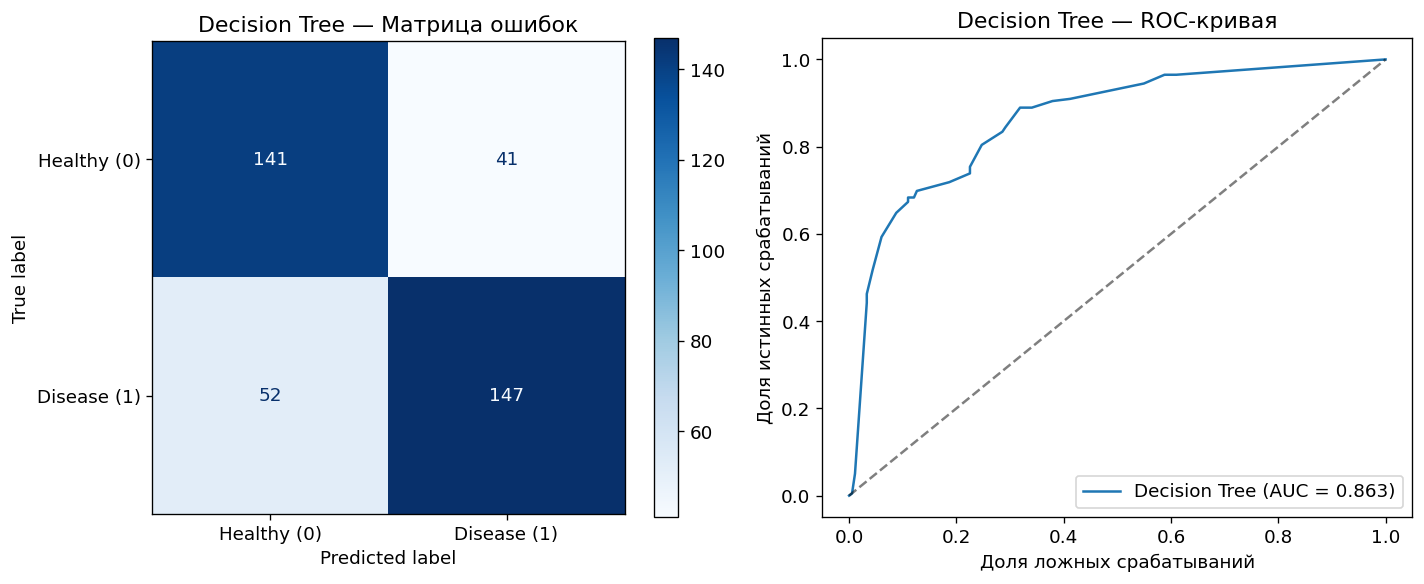

CPU times: total: 1.72 s
Wall time: 9.71 s


In [6]:
%%time
dt_search = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid={
        'max_depth': [3, 5, 7, 10, 15, None],
        'min_samples_split': [2, 5, 10, 20],
        'min_samples_leaf': [1, 2, 5, 10],
        'ccp_alpha': [0.0, 0.001, 0.005, 0.01, 0.02, 0.05],
        'class_weight': [None, 'balanced']
    },
    cv=cv, scoring='roc_auc', n_jobs=-1
)
dt_search.fit(X_train_scaled, y_train)
dt_model = dt_search.best_estimator_
print('Best params:', dt_search.best_params_)
evaluate_model('Decision Tree', dt_model, X_train_scaled, X_test_scaled, y_train, y_test)
plot_cm_roc('Decision Tree', dt_model, X_test_scaled, y_test, 'dt')

Best params: {'C': np.float64(144.4250213512539), 'max_iter': 3000, 'penalty': 'l1', 'solver': 'saga'}


Logistic Regression       | CV AUC: 0.8384 | Test AUC: 0.8475 | Test F1: 0.7865 | Brier: 0.1560 | Gap: 0.0008 [OK]


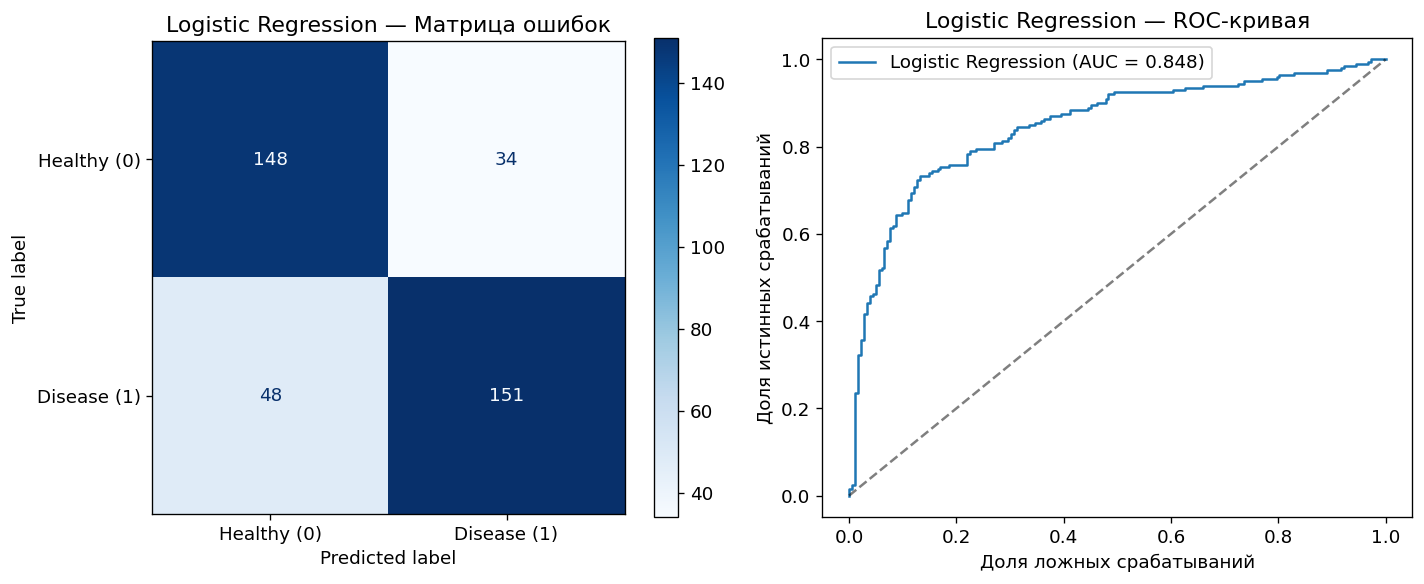

CPU times: total: 844 ms
Wall time: 4.24 s


In [7]:
%%time
lr_search = RandomizedSearchCV(
    LogisticRegression(random_state=RANDOM_STATE),
    param_distributions=[
        {'penalty': ['l1', 'l2'], 'C': loguniform(1e-3, 1e3),
         'solver': ['saga'], 'max_iter': [3000]},
        {'penalty': ['elasticnet'], 'C': loguniform(1e-3, 1e3),
         'l1_ratio': uniform(0.1, 0.8), 'solver': ['saga'], 'max_iter': [3000]}
    ],
    n_iter=80, cv=cv, scoring='roc_auc', n_jobs=-1, random_state=RANDOM_STATE
)
lr_search.fit(X_train_scaled, y_train)
lr_model = lr_search.best_estimator_
print('Best params:', lr_search.best_params_)
evaluate_model('Logistic Regression', lr_model, X_train_scaled, X_test_scaled, y_train, y_test)
plot_cm_roc('Logistic Regression', lr_model, X_test_scaled, y_test, 'lr')

Best params: {'bootstrap': True, 'class_weight': 'balanced_subsample', 'max_depth': 15, 'max_features': 0.3, 'max_samples': np.float64(0.9004746473411999), 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 479}


Random Forest             | CV AUC: 0.8985 | Test AUC: 0.9090 | Test F1: 0.8402 | Brier: 0.1239 | Gap: 0.1445 [OVERFIT]


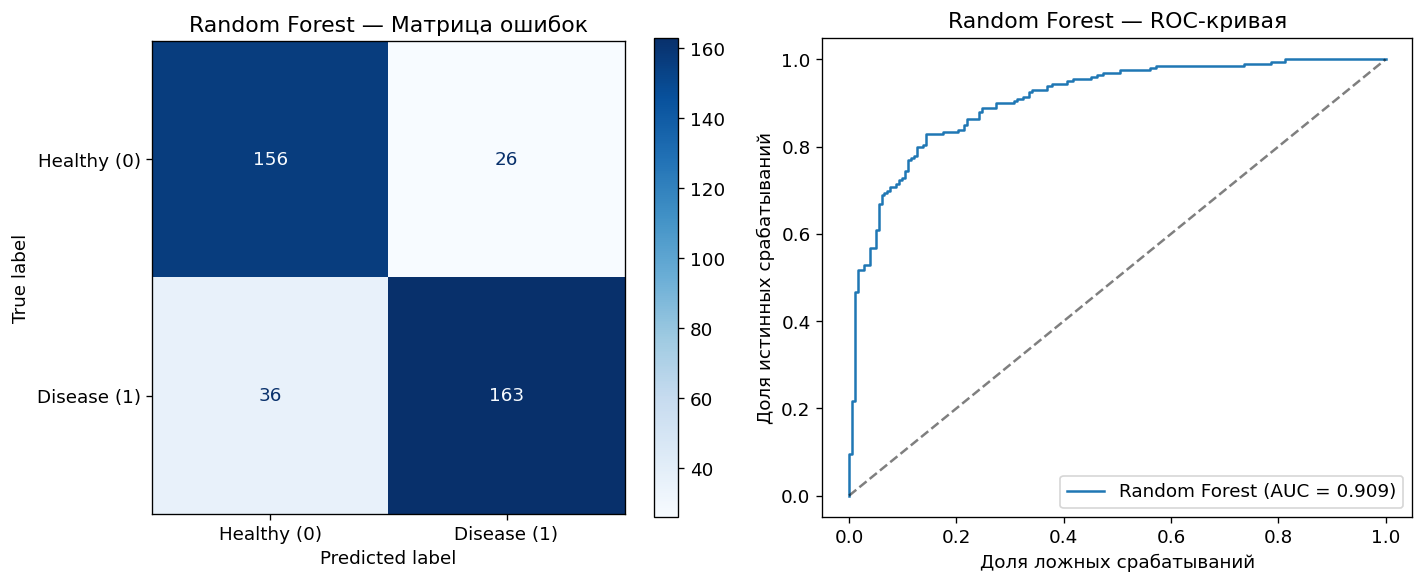

CPU times: total: 1.61 s
Wall time: 42.5 s


In [8]:
%%time
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_distributions={
        'n_estimators': randint(100, 600),
        'max_depth': [5, 7, 10, 15, 20, None],
        'min_samples_split': randint(2, 20),
        'min_samples_leaf': randint(1, 10),
        'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7],
        'bootstrap': [True],
        'max_samples': uniform(0.5, 0.5),
        'class_weight': ['balanced_subsample']
    },
    n_iter=80, cv=cv, scoring='roc_auc', n_jobs=-1, random_state=RANDOM_STATE
)
rf_search.fit(X_train, y_train)
rf_model = rf_search.best_estimator_
print('Best params:', rf_search.best_params_)
evaluate_model('Random Forest', rf_model, X_train, X_test, y_train, y_test)
plot_cm_roc('Random Forest', rf_model, X_test, y_test, 'rf')

Best params: {'colsample_bytree': np.float64(0.7383790552113019), 'gamma': np.float64(0.332759112738434), 'learning_rate': np.float64(0.007204250295148005), 'max_depth': 11, 'min_child_weight': 1, 'n_estimators': 624, 'reg_alpha': np.float64(0.236793520402239), 'reg_lambda': np.float64(0.5204862686958023), 'subsample': np.float64(0.8945856193036692)}


XGBoost                   | CV AUC: 0.9028 | Test AUC: 0.9232 | Test F1: 0.8368 | Brier: 0.1118 | Gap: 0.1466 [OVERFIT]


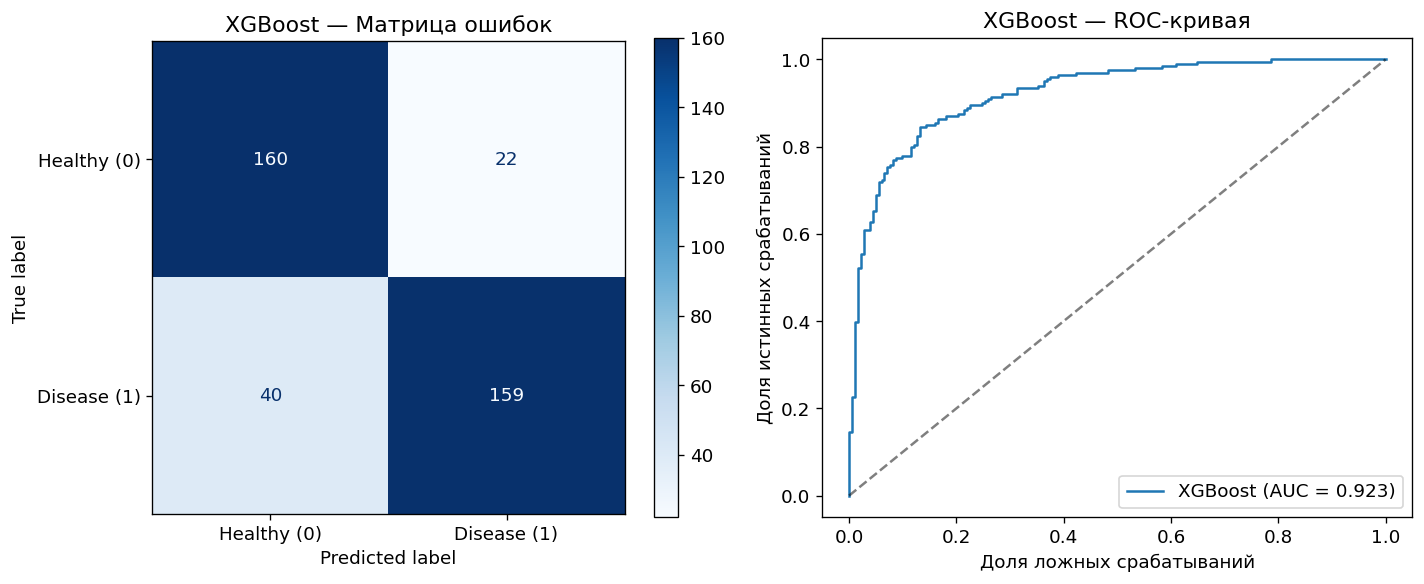

CPU times: total: 11.6 s
Wall time: 5.52 s


In [9]:
%%time
spw = (y_train == 0).sum() / (y_train == 1).sum()

xgb_search = RandomizedSearchCV(
    XGBClassifier(
        random_state=RANDOM_STATE, tree_method='hist', eval_metric='logloss',
        scale_pos_weight=spw, device='cpu', use_label_encoder=False
    ),
    param_distributions={
        'n_estimators': randint(100, 800),
        'max_depth': randint(3, 12),
        'learning_rate': loguniform(0.005, 0.3),
        'subsample': uniform(0.5, 0.5),
        'colsample_bytree': uniform(0.4, 0.6),
        'min_child_weight': randint(1, 10),
        'gamma': loguniform(1e-3, 1.0),
        'reg_alpha': loguniform(1e-3, 10),
        'reg_lambda': loguniform(1e-3, 10),
    },
    n_iter=100, cv=cv, scoring='roc_auc', n_jobs=-1, random_state=RANDOM_STATE
)
xgb_search.fit(X_train, y_train)
xgb_model = xgb_search.best_estimator_
print('Best params:', xgb_search.best_params_)
evaluate_model('XGBoost', xgb_model, X_train, X_test, y_train, y_test)
plot_cm_roc('XGBoost', xgb_model, X_test, y_test, 'xgb')

Best params: {'iterations': 500, 'depth': 9, 'learning_rate': 0.1001303991139125, 'l2_leaf_reg': 0.6251373574521749, 'border_count': 66, 'bagging_temperature': 0.3119890406724053, 'random_strength': 0.11616722433639892}


CatBoost                  | CV AUC: 0.9267 | Test AUC: 0.9475 | Test F1: 0.8837 | Brier: 0.0972 | Gap: 0.1414 [OVERFIT]


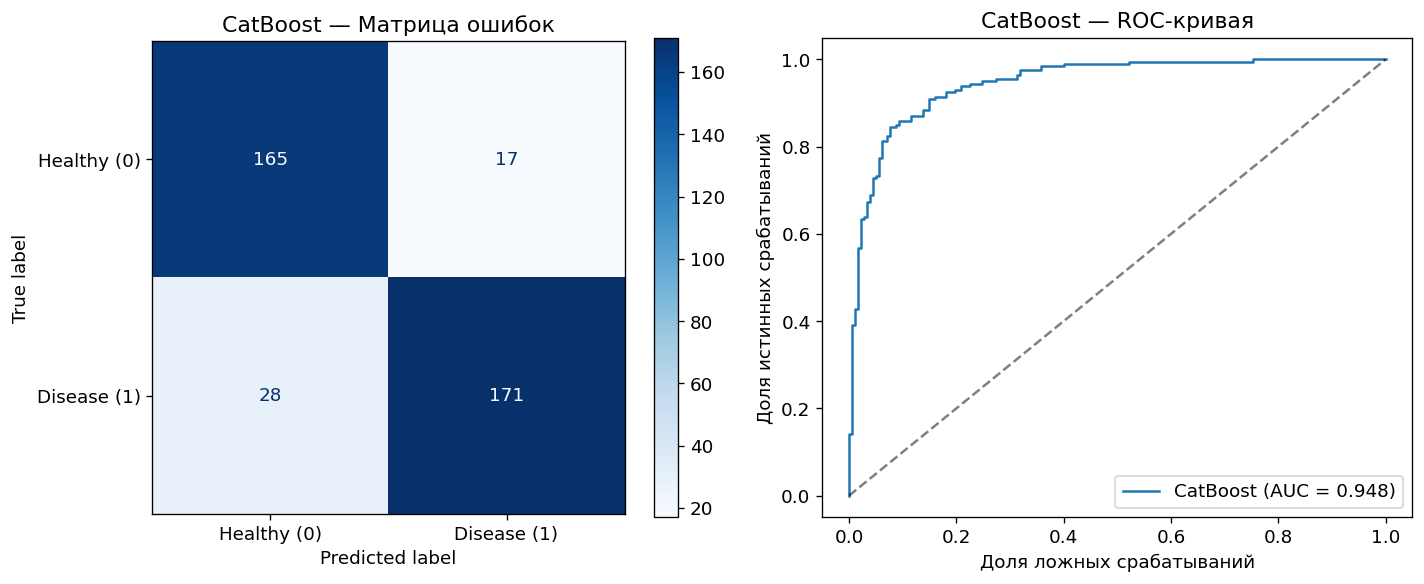

CPU times: total: 1h 52min 3s
Wall time: 11min 11s


In [10]:
%%time

def manual_cv_catboost(params, X_tr, y_tr, cv_splitter):
    scores = []
    for train_idx, val_idx in cv_splitter.split(X_tr, y_tr):
        cb = CatBoostClassifier(
            random_state=RANDOM_STATE, verbose=0, auto_class_weights='Balanced',
            od_type='Iter', od_wait=30, thread_count=-1, **params
        )
        cb.fit(X_tr.iloc[train_idx], y_tr.iloc[train_idx])
        y_proba = cb.predict_proba(X_tr.iloc[val_idx])[:, 1]
        scores.append(roc_auc_score(y_tr.iloc[val_idx], y_proba))
    return np.mean(scores)

def cb_objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 200, 1000),
        'depth': trial.suggest_int('depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-2, 10, log=True),
        'border_count': trial.suggest_int('border_count', 32, 254),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 2),
        'random_strength': trial.suggest_float('random_strength', 0, 2),
    }
    return manual_cv_catboost(params, X_train, y_train, cv)

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(cb_objective, n_trials=100, show_progress_bar=False)

cb_model = CatBoostClassifier(
    random_state=RANDOM_STATE, verbose=0, auto_class_weights='Balanced',
    od_type='Iter', od_wait=30, thread_count=-1, **study.best_params
)
cb_model.fit(X_train, y_train)
print('Best params:', study.best_params)
evaluate_model('CatBoost', cb_model, X_train, X_test, y_train, y_test, use_manual_cv=True)
plot_cm_roc('CatBoost', cb_model, X_test, y_test, 'cb')

Best params: {'colsample_bytree': np.float64(0.5923853152957086), 'learning_rate': np.float64(0.056883194357923245), 'max_depth': 8, 'min_child_samples': 14, 'n_estimators': 360, 'num_leaves': 37, 'reg_alpha': np.float64(0.15692347598835626), 'reg_lambda': np.float64(0.006410942022078958), 'subsample': np.float64(0.8422857739399167)}


LightGBM                  | CV AUC: 0.8995 | Test AUC: 0.9169 | Test F1: 0.8394 | Brier: 0.1189 | Gap: 0.1589 [OVERFIT]


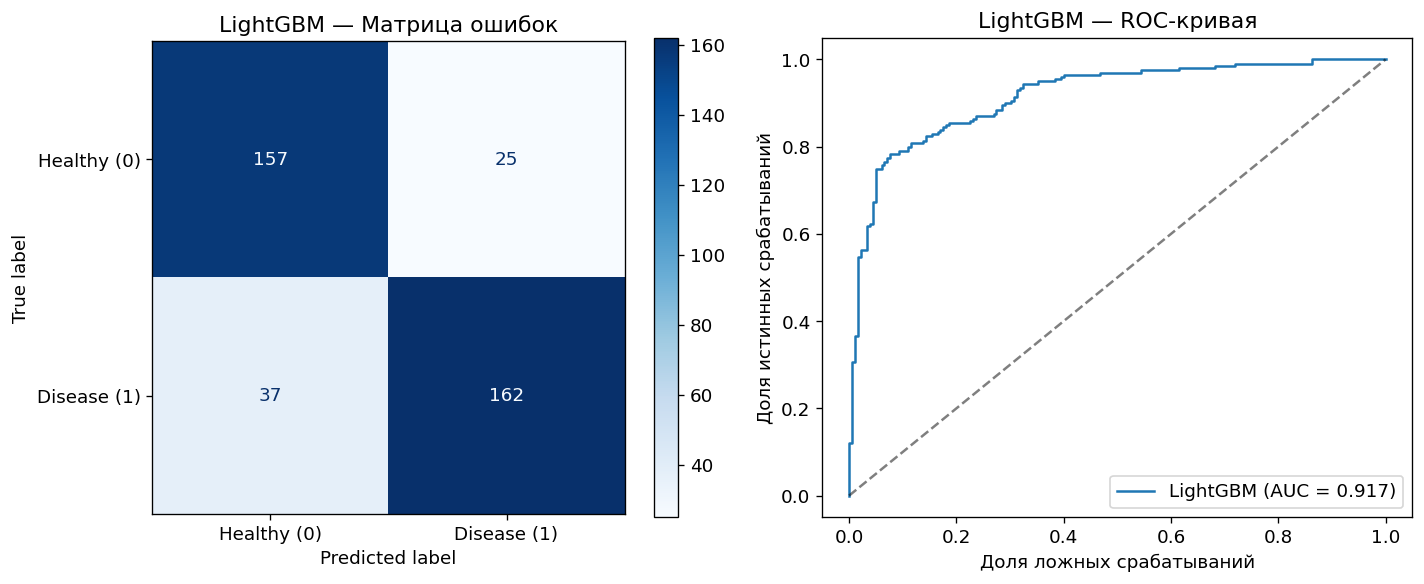

CPU times: total: 5.3 s
Wall time: 1min 22s


In [11]:
%%time
lgb_search = RandomizedSearchCV(
    LGBMClassifier(random_state=RANDOM_STATE, class_weight='balanced', verbose=-1),
    param_distributions={
        'n_estimators': randint(100, 800),
        'max_depth': randint(3, 12),
        'learning_rate': loguniform(0.005, 0.3),
        'subsample': uniform(0.5, 0.5),
        'colsample_bytree': uniform(0.4, 0.6),
        'min_child_samples': randint(5, 50),
        'reg_alpha': loguniform(1e-3, 10),
        'reg_lambda': loguniform(1e-3, 10),
        'num_leaves': randint(15, 127),
    },
    n_iter=100, cv=cv, scoring='roc_auc', n_jobs=-1, random_state=RANDOM_STATE
)
lgb_search.fit(X_train, y_train)
lgb_model = lgb_search.best_estimator_
print('Best params:', lgb_search.best_params_)
evaluate_model('LightGBM', lgb_model, X_train, X_test, y_train, y_test)
plot_cm_roc('LightGBM', lgb_model, X_test, y_test, 'lgb')

---
## Раздел 2. Стекинг-ансамбль

Ручная генерация OOF-предсказаний от 6 базовых моделей, мета-обучающийся (логистическая регрессия), калибровка Platt scaling.


In [12]:
lgb_imp        = pd.Series(lgb_model.feature_importances_, index=ALL_FEATURES).nlargest(7)
top_meta_feats = lgb_imp.index.tolist()

sc_meta          = StandardScaler()
X_meta_ext_train = sc_meta.fit_transform(X_train[top_meta_feats])
X_meta_ext_test  = sc_meta.transform(X_test[top_meta_feats])

base_models_registry = [
    ('DT',  dt_model,  True,  False),
    ('LR',  lr_model,  True,  False),
    ('RF',  rf_model,  False, False),
    ('XGB', xgb_model, False, False),
    ('CB',  cb_model,  False, True),
    ('LGB', lgb_model, False, False),
]

n_train  = X_train.shape[0]
n_test   = X_test.shape[0]
n_models = len(base_models_registry)
oof_train = np.zeros((n_train, n_models))
oof_test  = np.zeros((n_test,  n_models))

for i, (tag, model, needs_scale, manual_fit) in enumerate(base_models_registry):
    oof_test_folds = np.zeros((n_test, 5))

    for j, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
        X_tr_fold  = X_train.iloc[train_idx].copy()
        X_val_fold = X_train.iloc[val_idx].copy()
        X_te_fold  = X_test.copy()

        if needs_scale:
            fold_scaler = StandardScaler()
            X_tr_fold[NUM_COLS]  = fold_scaler.fit_transform(X_tr_fold[NUM_COLS])
            X_val_fold[NUM_COLS] = fold_scaler.transform(X_val_fold[NUM_COLS])
            X_te_fold[NUM_COLS]  = fold_scaler.transform(X_te_fold[NUM_COLS])

        if manual_fit:
            m = CatBoostClassifier(
                random_state=RANDOM_STATE, verbose=0, auto_class_weights='Balanced',
                od_type='Iter', od_wait=30, thread_count=-1, **study.best_params
            )
        else:
            m = model.__class__(**model.get_params())

        m.fit(X_tr_fold, y_train.iloc[train_idx])
        oof_train[val_idx, i] = m.predict_proba(X_val_fold)[:, 1]
        oof_test_folds[:, j]  = m.predict_proba(X_te_fold)[:, 1]

    oof_test[:, i] = oof_test_folds.mean(axis=1)

oof_train_ext = np.hstack([oof_train, X_meta_ext_train])
oof_test_ext  = np.hstack([oof_test,  X_meta_ext_test])

In [13]:
from scipy.optimize import minimize

c_grid   = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]
cv_meta  = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
c_scores = {}
for c in c_grid:
    fold_aucs = []
    for tr_idx, va_idx in cv_meta.split(oof_train_ext, y_train):
        m = LogisticRegression(C=c, random_state=RANDOM_STATE, max_iter=1000)
        m.fit(oof_train_ext[tr_idx], y_train.iloc[tr_idx])
        fold_aucs.append(roc_auc_score(y_train.iloc[va_idx],
                                       m.predict_proba(oof_train_ext[va_idx])[:, 1]))
    c_scores[c] = np.mean(fold_aucs)

best_c     = max(c_scores, key=c_scores.get)
meta_model = LogisticRegression(C=best_c, random_state=RANDOM_STATE, max_iter=1000)
meta_model.fit(oof_train_ext, y_train)
stack_proba_raw = meta_model.predict_proba(oof_test_ext)[:, 1]

oof_meta_proba = meta_model.predict_proba(oof_train_ext)[:, 1]

def platt_nll(params, probs, labels):
    a, b    = params
    logits  = np.log(probs / (1 - probs + 1e-15) + 1e-15)
    cal     = 1.0 / (1.0 + np.exp(-(a * logits + b)))
    cal     = np.clip(cal, 1e-15, 1 - 1e-15)
    return -np.mean(labels * np.log(cal) + (1 - labels) * np.log(1 - cal))

result   = minimize(platt_nll, x0=[1.0, 0.0],
                    args=(oof_meta_proba, y_train.values), method='L-BFGS-B')
platt_a, platt_b = result.x

def platt_calibrate(probs, a, b):
    logits = np.log(probs / (1 - probs + 1e-15) + 1e-15)
    return 1.0 / (1.0 + np.exp(-(a * logits + b)))

stack_proba = platt_calibrate(stack_proba_raw, platt_a, platt_b)
stack_pred  = (stack_proba >= 0.5).astype(int)

results['Stacking'] = {
    'Test_Accuracy':  accuracy_score(y_test, stack_pred),
    'Test_Precision': precision_score(y_test, stack_pred),
    'Test_Recall':    recall_score(y_test, stack_pred),
    'Test_F1':        f1_score(y_test, stack_pred),
    'Test_ROC_AUC':   roc_auc_score(y_test, stack_proba),
    'Test_Brier':     brier_score_loss(y_test, stack_proba),
}

print(f'Optimal meta C: {best_c}')
print(f'Stacking  AUC : {results["Stacking"]["Test_ROC_AUC"]:.4f}')
print(f'Stacking  F1  : {results["Stacking"]["Test_F1"]:.4f}')
print(f'Stacking Brier: {results["Stacking"]["Test_Brier"]:.4f}')

Optimal meta C: 0.5
Stacking  AUC : 0.9308
Stacking  F1  : 0.8684
Stacking Brier: 0.1023


---
## Раздел 3. Ансамбль мягкого голосования

Два варианта: равные веса и взвешивание по AUC.


In [14]:
all_models_for_voting = [
    ('Decision Tree',       dt_model,  X_test_scaled),
    ('Logistic Regression', lr_model,  X_test_scaled),
    ('Random Forest',       rf_model,  X_test),
    ('XGBoost',             xgb_model, X_test),
    ('CatBoost',            cb_model,  X_test),
    ('LightGBM',            lgb_model, X_test),
]

test_probas = {}
for name, model, X_te in all_models_for_voting:
    test_probas[name] = model.predict_proba(X_te)[:, 1]

proba_matrix = np.column_stack(list(test_probas.values()))
vote_equal_proba = proba_matrix.mean(axis=1)
vote_equal_pred = (vote_equal_proba >= 0.5).astype(int)

base_aucs = np.array([results[name]['Test_ROC_AUC'] for name in test_probas.keys()])
weights = base_aucs / base_aucs.sum()
vote_weighted_proba = (proba_matrix * weights).sum(axis=1)
vote_weighted_pred = (vote_weighted_proba >= 0.5).astype(int)

print('=== Equal-weight Soft Voting ===')
print(f'  ROC-AUC: {roc_auc_score(y_test, vote_equal_proba):.4f}')
print(f'  F1:      {f1_score(y_test, vote_equal_pred):.4f}')
print(f'  Brier:   {brier_score_loss(y_test, vote_equal_proba):.4f}')

print('\n=== AUC-weighted Soft Voting ===')
print(f'  ROC-AUC: {roc_auc_score(y_test, vote_weighted_proba):.4f}')
print(f'  F1:      {f1_score(y_test, vote_weighted_pred):.4f}')
print(f'  Brier:   {brier_score_loss(y_test, vote_weighted_proba):.4f}')
print(f'  Weights: {dict(zip(test_probas.keys(), weights.round(3)))}')

voting_proba = vote_weighted_proba
voting_pred = vote_weighted_pred

results['Voting'] = {
    'Test_Accuracy': accuracy_score(y_test, voting_pred),
    'Test_Precision': precision_score(y_test, voting_pred),
    'Test_Recall': recall_score(y_test, voting_pred),
    'Test_F1': f1_score(y_test, voting_pred),
    'Test_ROC_AUC': roc_auc_score(y_test, voting_proba),
    'Test_Brier': brier_score_loss(y_test, voting_proba),
}

=== Equal-weight Soft Voting ===
  ROC-AUC: 0.9273
  F1:      0.8480
  Brier:   0.1081

=== AUC-weighted Soft Voting ===
  ROC-AUC: 0.9284
  F1:      0.8533
  Brier:   0.1074
  Weights: {'Decision Tree': np.float64(0.16), 'Logistic Regression': np.float64(0.157), 'Random Forest': np.float64(0.168), 'XGBoost': np.float64(0.171), 'CatBoost': np.float64(0.175), 'LightGBM': np.float64(0.17)}


---
## Раздел 4. Бутстреп-доверительные интервалы

2000 бутстреп-выборок, 95% ДИ для всех метрик по всем 8 моделям.


In [15]:
def _metric(yt, yp, ypr, name):
    if len(np.unique(yt)) < 2:
        return np.nan
    if name == 'Accuracy':  return accuracy_score(yt, ypr)
    if name == 'Precision': return precision_score(yt, ypr, zero_division=0)
    if name == 'Recall':    return recall_score(yt, ypr, zero_division=0)
    if name == 'F1':        return f1_score(yt, ypr, zero_division=0)
    if name == 'ROC_AUC':   return roc_auc_score(yt, yp)
    if name == 'Brier':     return brier_score_loss(yt, yp)

def _bca(obs, boot, jack, alpha=0.05):
    jack = jack[~np.isnan(jack)]
    z0   = stats.norm.ppf(np.clip(np.mean(boot < obs), 1e-6, 1 - 1e-6))
    jm   = jack.mean()
    a    = np.sum((jm - jack)**3) / (6 * np.sum((jm - jack)**2)**1.5 + 1e-15)
    za, z1a = stats.norm.ppf(alpha / 2), stats.norm.ppf(1 - alpha / 2)
    plo  = stats.norm.cdf(z0 + (z0 + za)  / (1 - a * (z0 + za)))
    phi  = stats.norm.cdf(z0 + (z0 + z1a) / (1 - a * (z0 + z1a)))
    return np.percentile(boot, [100 * np.clip(plo, 0.001, 0.999),
                                100 * np.clip(phi, 0.001, 0.999)])

def bootstrap_metrics(y_true, y_proba, y_pred, n_boot=2000, seed=42):
    rng    = np.random.RandomState(seed)
    n      = len(y_true)
    y_arr  = y_true.values
    mnames = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC', 'Brier']
    bvals  = {m: [] for m in mnames}

    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        yt, yp, ypr = y_arr[idx], y_proba[idx], y_pred[idx]
        for m in mnames:
            v = _metric(yt, yp, ypr, m)
            if v is not None and not np.isnan(v):
                bvals[m].append(v)

    result = {}
    for m in mnames:
        boot = np.array(bvals[m])
        obs  = _metric(y_arr, y_proba, y_pred, m)
        jack = np.array([_metric(np.delete(y_arr, i),
                                 np.delete(y_proba, i),
                                 np.delete(y_pred,  i), m) for i in range(n)])
        lo, hi = _bca(obs, boot, jack)
        result[m] = {'mean': boot.mean(), 'lo': lo, 'hi': hi}
    return result

all_model_preds = {
    'Decision Tree':       (dt_model.predict_proba(X_test_scaled)[:, 1],
                            dt_model.predict(X_test_scaled)),
    'Logistic Regression': (lr_model.predict_proba(X_test_scaled)[:, 1],
                            lr_model.predict(X_test_scaled)),
    'Random Forest':       (rf_model.predict_proba(X_test)[:, 1],
                            rf_model.predict(X_test)),
    'XGBoost':             (xgb_model.predict_proba(X_test)[:, 1],
                            xgb_model.predict(X_test)),
    'CatBoost':            (cb_model.predict_proba(X_test)[:, 1],
                            cb_model.predict(X_test)),
    'LightGBM':            (lgb_model.predict_proba(X_test)[:, 1],
                            lgb_model.predict(X_test)),
    'Stacking':            (stack_proba, stack_pred),
    'Voting':              (voting_proba, voting_pred),
}

boot_results = {}
for name, (yp, ypred) in all_model_preds.items():
    boot_results[name] = bootstrap_metrics(y_test, yp, ypred)
    r = boot_results[name]
    print(f'{name:25s}  AUC {r["ROC_AUC"]["mean"]:.4f} '
          f'[{r["ROC_AUC"]["lo"]:.4f}-{r["ROC_AUC"]["hi"]:.4f}]  '
          f'F1 {r["F1"]["mean"]:.4f} [{r["F1"]["lo"]:.4f}-{r["F1"]["hi"]:.4f}]')

Decision Tree              AUC 0.8640 [0.8226-0.8974]  F1 0.7601 [0.7077-0.8058]


Logistic Regression        AUC 0.8480 [0.8063-0.8841]  F1 0.7864 [0.7407-0.8315]


Random Forest              AUC 0.9093 [0.8761-0.9346]  F1 0.8403 [0.7989-0.8762]


XGBoost                    AUC 0.9236 [0.8940-0.9472]  F1 0.8370 [0.7932-0.8740]


CatBoost                   AUC 0.9477 [0.9222-0.9661]  F1 0.8844 [0.8485-0.9156]


LightGBM                   AUC 0.9171 [0.8847-0.9421]  F1 0.8392 [0.7960-0.8766]


Stacking                   AUC 0.9313 [0.9007-0.9529]  F1 0.8687 [0.8293-0.9034]


Voting                     AUC 0.9289 [0.8973-0.9503]  F1 0.8534 [0.8116-0.8906]


In [16]:
pub_rows = []
for name in all_model_preds.keys():
    br = boot_results[name]
    row = {'Model': name}
    for metric in ['ROC_AUC', 'F1', 'Accuracy', 'Brier']:
        m = br[metric]
        row[f'{metric}'] = f'{m["mean"]:.4f} [{m["lo"]:.4f}-{m["hi"]:.4f}]'
    pub_rows.append(row)

pub_table = pd.DataFrame(pub_rows).set_index('Model')
print(pub_table.to_string())
pub_table.to_csv(f'{REPORTS}/metrics_bootstrap.csv')

                                    ROC_AUC                      F1                Accuracy                   Brier
Model                                                                                                              
Decision Tree        0.8640 [0.8226-0.8974]  0.7601 [0.7077-0.8058]  0.7566 [0.7060-0.7953]  0.1496 [0.1273-0.1751]
Logistic Regression  0.8480 [0.8063-0.8841]  0.7864 [0.7407-0.8315]  0.7851 [0.7428-0.8241]  0.1557 [0.1363-0.1779]
Random Forest        0.9093 [0.8761-0.9346]  0.8403 [0.7989-0.8762]  0.8377 [0.7953-0.8688]  0.1236 [0.1072-0.1429]
XGBoost              0.9236 [0.8940-0.9472]  0.8370 [0.7932-0.8740]  0.8378 [0.7953-0.8714]  0.1115 [0.0928-0.1321]
CatBoost             0.9477 [0.9222-0.9661]  0.8844 [0.8485-0.9156]  0.8828 [0.8451-0.9108]  0.0967 [0.0738-0.1242]
LightGBM             0.9171 [0.8847-0.9421]  0.8392 [0.7960-0.8766]  0.8374 [0.7953-0.8714]  0.1187 [0.0956-0.1457]
Stacking             0.9313 [0.9007-0.9529]  0.8687 [0.8293-0.9034]  0.8

---
## Раздел 5. Статистические тесты

Тест DeLong (сравнение ROC-AUC) и тест МакНемара (бинарные предсказания) с поправкой Бонферрони.


In [17]:
def delong_roc_variance(ground_truth, predictions):
    """Compute variance of AUC via DeLong method (numpy/scipy only)."""
    ground_truth = np.asarray(ground_truth)
    predictions = np.asarray(predictions)
    pos_idx = np.where(ground_truth == 1)[0]
    neg_idx = np.where(ground_truth == 0)[0]
    m, n = len(pos_idx), len(neg_idx)

    pos_scores = predictions[pos_idx]
    neg_scores = predictions[neg_idx]

    V10 = np.zeros(m)
    V01 = np.zeros(n)
    for i, ps in enumerate(pos_scores):
        V10[i] = np.mean((neg_scores < ps) + 0.5 * (neg_scores == ps))
    for j, ns in enumerate(neg_scores):
        V01[j] = np.mean((pos_scores > ns) + 0.5 * (pos_scores == ns))

    auc = V10.mean()
    s10 = np.var(V10, ddof=1) / m
    s01 = np.var(V01, ddof=1) / n
    var_auc = s10 + s01
    return auc, var_auc

def delong_test(y_true, proba1, proba2):
    """DeLong test for comparing two ROC-AUC values. Returns z-statistic and p-value."""
    y_true = np.asarray(y_true)
    auc1, var1 = delong_roc_variance(y_true, proba1)
    auc2, var2 = delong_roc_variance(y_true, proba2)

    pos_idx = np.where(y_true == 1)[0]
    neg_idx = np.where(y_true == 0)[0]
    pos1, pos2 = proba1[pos_idx], proba2[pos_idx]
    neg1, neg2 = proba1[neg_idx], proba2[neg_idx]
    m, n = len(pos_idx), len(neg_idx)

    V10_1 = np.array([np.mean((neg1 < ps) + 0.5 * (neg1 == ps)) for ps in pos1])
    V10_2 = np.array([np.mean((neg2 < ps) + 0.5 * (neg2 == ps)) for ps in pos2])
    V01_1 = np.array([np.mean((pos1 > ns) + 0.5 * (pos1 == ns)) for ns in neg1])
    V01_2 = np.array([np.mean((pos2 > ns) + 0.5 * (pos2 == ns)) for ns in neg2])

    cov10 = np.cov(V10_1, V10_2, ddof=1)[0, 1] / m
    cov01 = np.cov(V01_1, V01_2, ddof=1)[0, 1] / n
    cov = cov10 + cov01

    se = np.sqrt(var1 + var2 - 2 * cov)
    if se < 1e-10:
        return 0.0, 1.0
    z = (auc1 - auc2) / se
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return z, p

Bonferroni threshold (α=0.05, 28 pairs): p < 0.00179


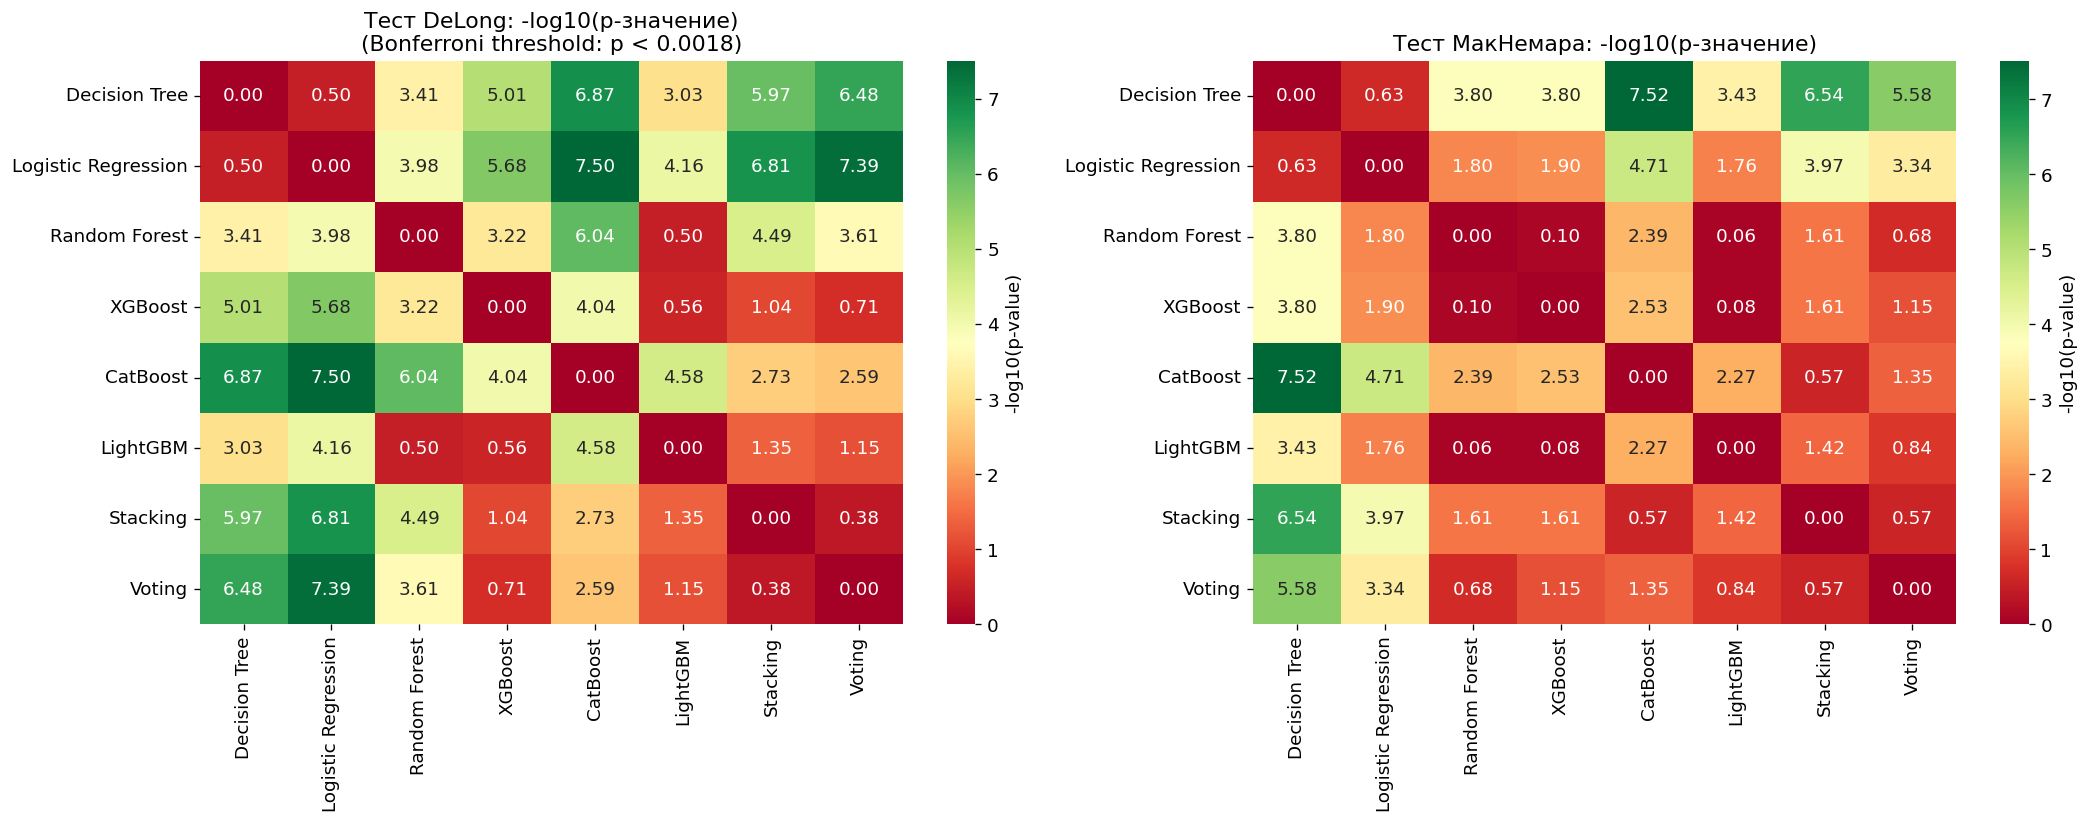

In [18]:
model_names = list(all_model_preds.keys())
n_m = len(model_names)
n_pairs = n_m * (n_m - 1) // 2
delong_pval_matrix = np.ones((n_m, n_m))
mcnemar_pval_matrix = np.ones((n_m, n_m))

for i in range(n_m):
    for j in range(i + 1, n_m):
        p1 = all_model_preds[model_names[i]][0]
        p2 = all_model_preds[model_names[j]][0]
        pred1 = all_model_preds[model_names[i]][1]
        pred2 = all_model_preds[model_names[j]][1]

        _, pval = delong_test(y_test.values, p1, p2)
        delong_pval_matrix[i, j] = pval
        delong_pval_matrix[j, i] = pval

        b = np.sum((pred1 == y_test.values) & (pred2 != y_test.values))
        c = np.sum((pred1 != y_test.values) & (pred2 == y_test.values))
        if b + c > 0:
            chi2 = (abs(b - c) - 1) ** 2 / (b + c)
            mcnemar_p = 1 - stats.chi2.cdf(chi2, df=1)
        else:
            mcnemar_p = 1.0
        mcnemar_pval_matrix[i, j] = mcnemar_p
        mcnemar_pval_matrix[j, i] = mcnemar_p

alpha = 0.05
bonferroni_threshold = alpha / n_pairs
print(f'Bonferroni threshold (α={alpha}, {n_pairs} pairs): p < {bonferroni_threshold:.5f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

delong_log = -np.log10(delong_pval_matrix + 1e-10)
np.fill_diagonal(delong_log, 0)
sns.heatmap(delong_log, annot=True, fmt='.2f', xticklabels=model_names,
            yticklabels=model_names, cmap='RdYlGn', ax=ax1,
            cbar_kws={'label': '-log10(p-value)'})
ax1.set_title(f'Тест DeLong: -log10(p-значение)\n(Bonferroni threshold: p < {bonferroni_threshold:.4f})')

mcnemar_log = -np.log10(mcnemar_pval_matrix + 1e-10)
np.fill_diagonal(mcnemar_log, 0)
sns.heatmap(mcnemar_log, annot=True, fmt='.2f', xticklabels=model_names,
            yticklabels=model_names, cmap='RdYlGn', ax=ax2,
            cbar_kws={'label': '-log10(p-value)'})
ax2.set_title('Тест МакНемара: -log10(p-значение)')

plt.tight_layout()
plt.savefig(f'{FIGURES}/fig2_significance_heatmaps.png', bbox_inches='tight')
plt.show()

---
## Раздел 5б. NRI и IDI

Net Reclassification Improvement и Integrated Discrimination Improvement — стандартные метрики для сравнения клинических предсказательных моделей. Стекинг-ансамбль сравнивается с лучшей базовой моделью (CatBoost).


In [19]:
def nri_idi(y_true, p_new, p_ref):
    y    = np.asarray(y_true)
    ev   = y == 1
    nev  = y == 0
    nri_ev  = np.mean(p_new[ev]  > p_ref[ev])  - np.mean(p_new[ev]  < p_ref[ev])
    nri_nev = np.mean(p_new[nev] < p_ref[nev]) - np.mean(p_new[nev] > p_ref[nev])
    nri = nri_ev + nri_nev
    idi = (p_new[ev].mean() - p_ref[ev].mean()) - (p_new[nev].mean() - p_ref[nev].mean())
    return nri, nri_ev, nri_nev, idi

p_ref = all_model_preds['CatBoost'][0]
p_new = all_model_preds['Stacking'][0]
y_arr = y_test.values

nri_val, nri_ev, nri_nev, idi_val = nri_idi(y_arr, p_new, p_ref)

rng_b   = np.random.RandomState(RANDOM_STATE)
n       = len(y_arr)
nri_b, idi_b = [], []
for _ in range(2000):
    idx = rng_b.randint(0, n, n)
    yt, pn, pr = y_arr[idx], p_new[idx], p_ref[idx]
    if len(np.unique(yt)) < 2:
        continue
    nb_, _, _, ib_ = nri_idi(yt, pn, pr)
    nri_b.append(nb_)
    idi_b.append(ib_)

nri_b = np.array(nri_b)
idi_b = np.array(idi_b)

nri_idi_df = pd.DataFrame([
    {'Метрика':       'NRI (Стекинг vs CatBoost)',
     'Значение':      f'{nri_val:.4f}',
     '95% ДИ':        f'[{np.percentile(nri_b, 2.5):.4f}; {np.percentile(nri_b, 97.5):.4f}]',
     'NRI events':    f'{nri_ev:.4f}',
     'NRI non-events':f'{nri_nev:.4f}'},
    {'Метрика':       'IDI (Стекинг vs CatBoost)',
     'Значение':      f'{idi_val:.4f}',
     '95% ДИ':        f'[{np.percentile(idi_b, 2.5):.4f}; {np.percentile(idi_b, 97.5):.4f}]',
     'NRI events':    '—',
     'NRI non-events':'—'},
])
print(nri_idi_df.to_string(index=False))

joblib.dump(
    {'nri': nri_val, 'idi': idi_val,
     'nri_ci': (float(np.percentile(nri_b, 2.5)), float(np.percentile(nri_b, 97.5))),
     'idi_ci': (float(np.percentile(idi_b, 2.5)), float(np.percentile(idi_b, 97.5)))},
    f'{MODELS}/nri_idi_stats.pkl'
)

                  Метрика Значение             95% ДИ NRI events NRI non-events
NRI (Стекинг vs CatBoost)  -1.4696 [-1.6062; -1.3336]    -0.6784        -0.7912
IDI (Стекинг vs CatBoost)  -0.1587 [-0.1798; -0.1379]          —              —


['../models_v2_ru/nri_idi.pkl']

---
## Раздел 6. Повторная стратифицированная k-кратная кросс-валидация (5×5 = 25 оценок на модель)


In [20]:
%%time
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)

rkf_models = [
    ('Decision Tree',       dt_model,  X_train_scaled, X_test_scaled, False),
    ('Logistic Regression', lr_model,  X_train_scaled, X_test_scaled, False),
    ('Random Forest',       rf_model,  X_train,        X_test,        False),
    ('XGBoost',             xgb_model, X_train,        X_test,        False),
    ('LightGBM',            lgb_model, X_train,        X_test,        False),
]

rkf_results = {}
for name, model, X_tr, _, is_cb in rkf_models:
    scores = cross_validate(model, X_tr, y_train, cv=rskf,
                            scoring='roc_auc', n_jobs=-1)
    rkf_results[name] = scores['test_score']
    print(f'{name:25s} | Mean AUC: {scores["test_score"].mean():.4f} +/- {scores["test_score"].std():.4f}')

cb_rskf_scores = []
for train_idx, val_idx in rskf.split(X_train, y_train):
    m = CatBoostClassifier(
        random_state=RANDOM_STATE, verbose=0, auto_class_weights='Balanced',
        od_type='Iter', od_wait=30, thread_count=-1, **study.best_params
    )
    m.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
    val_proba = m.predict_proba(X_train.iloc[val_idx])[:, 1]
    cb_rskf_scores.append(roc_auc_score(y_train.iloc[val_idx], val_proba))
rkf_results['CatBoost'] = np.array(cb_rskf_scores)
print(f'{"CatBoost":25s} | Mean AUC: {np.mean(cb_rskf_scores):.4f} +/- {np.std(cb_rskf_scores):.4f}')

Decision Tree             | Mean AUC: 0.8388 +/- 0.0200


Logistic Regression       | Mean AUC: 0.8390 +/- 0.0218


Random Forest             | Mean AUC: 0.8961 +/- 0.0183


XGBoost                   | Mean AUC: 0.9010 +/- 0.0179


LightGBM                  | Mean AUC: 0.8973 +/- 0.0155


CatBoost                  | Mean AUC: 0.9230 +/- 0.0171
CPU times: total: 4min 25s
Wall time: 34.8 s


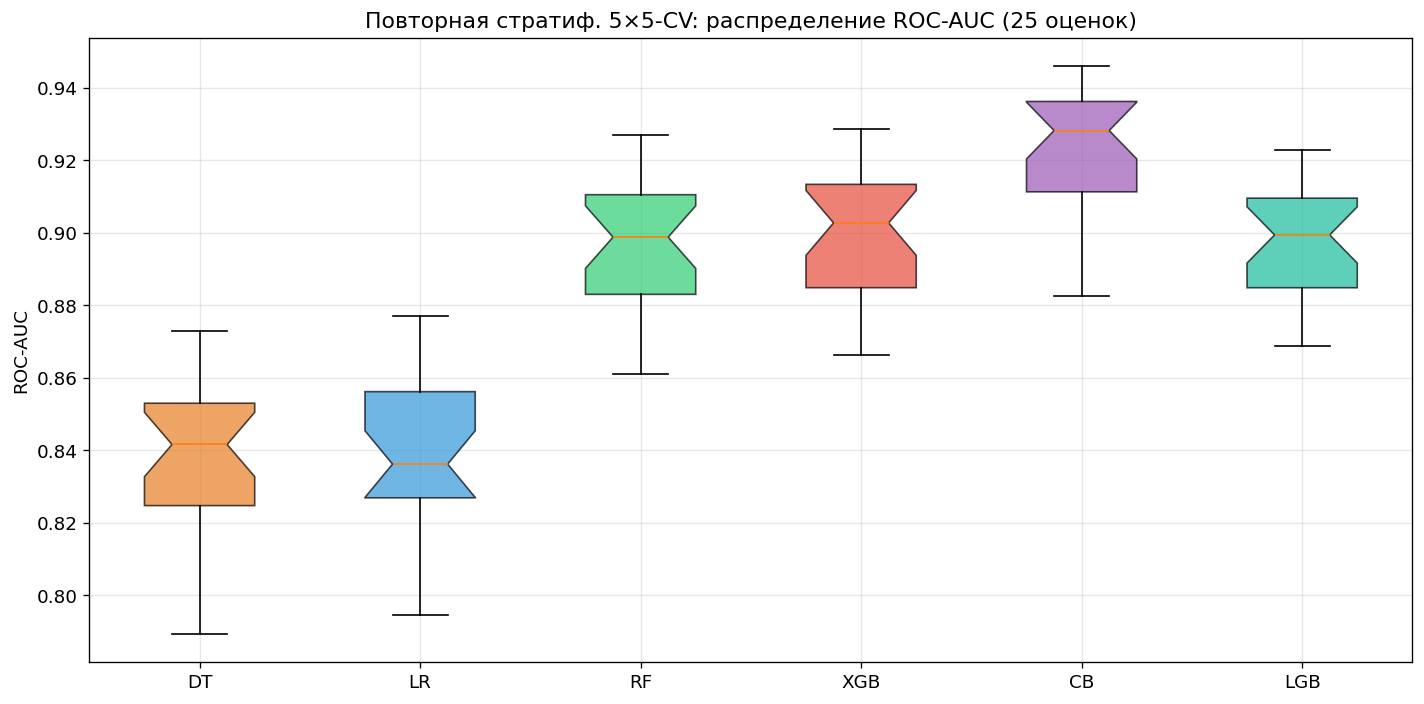

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))
rkf_data = [rkf_results[name] for name in ['Decision Tree', 'Logistic Regression',
                                             'Random Forest', 'XGBoost', 'CatBoost', 'LightGBM']]
bp = ax.boxplot(rkf_data, patch_artist=True, notch=True)
colors = ['#e67e22', '#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#1abc9c']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xticklabels(['DT', 'LR', 'RF', 'XGB', 'CB', 'LGB'], fontsize=11)
ax.set_ylabel('ROC-AUC')
ax.set_title('Повторная стратиф. 5×5-CV: распределение ROC-AUC (25 оценок)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURES}/fig9_repeated_cv.png', bbox_inches='tight')
plt.show()

---
## Раздел 7. Анализ калибровки

Диаграммы надёжности, ожидаемая ошибка калибровки (ECE), оценки Brier до/после калибровки.


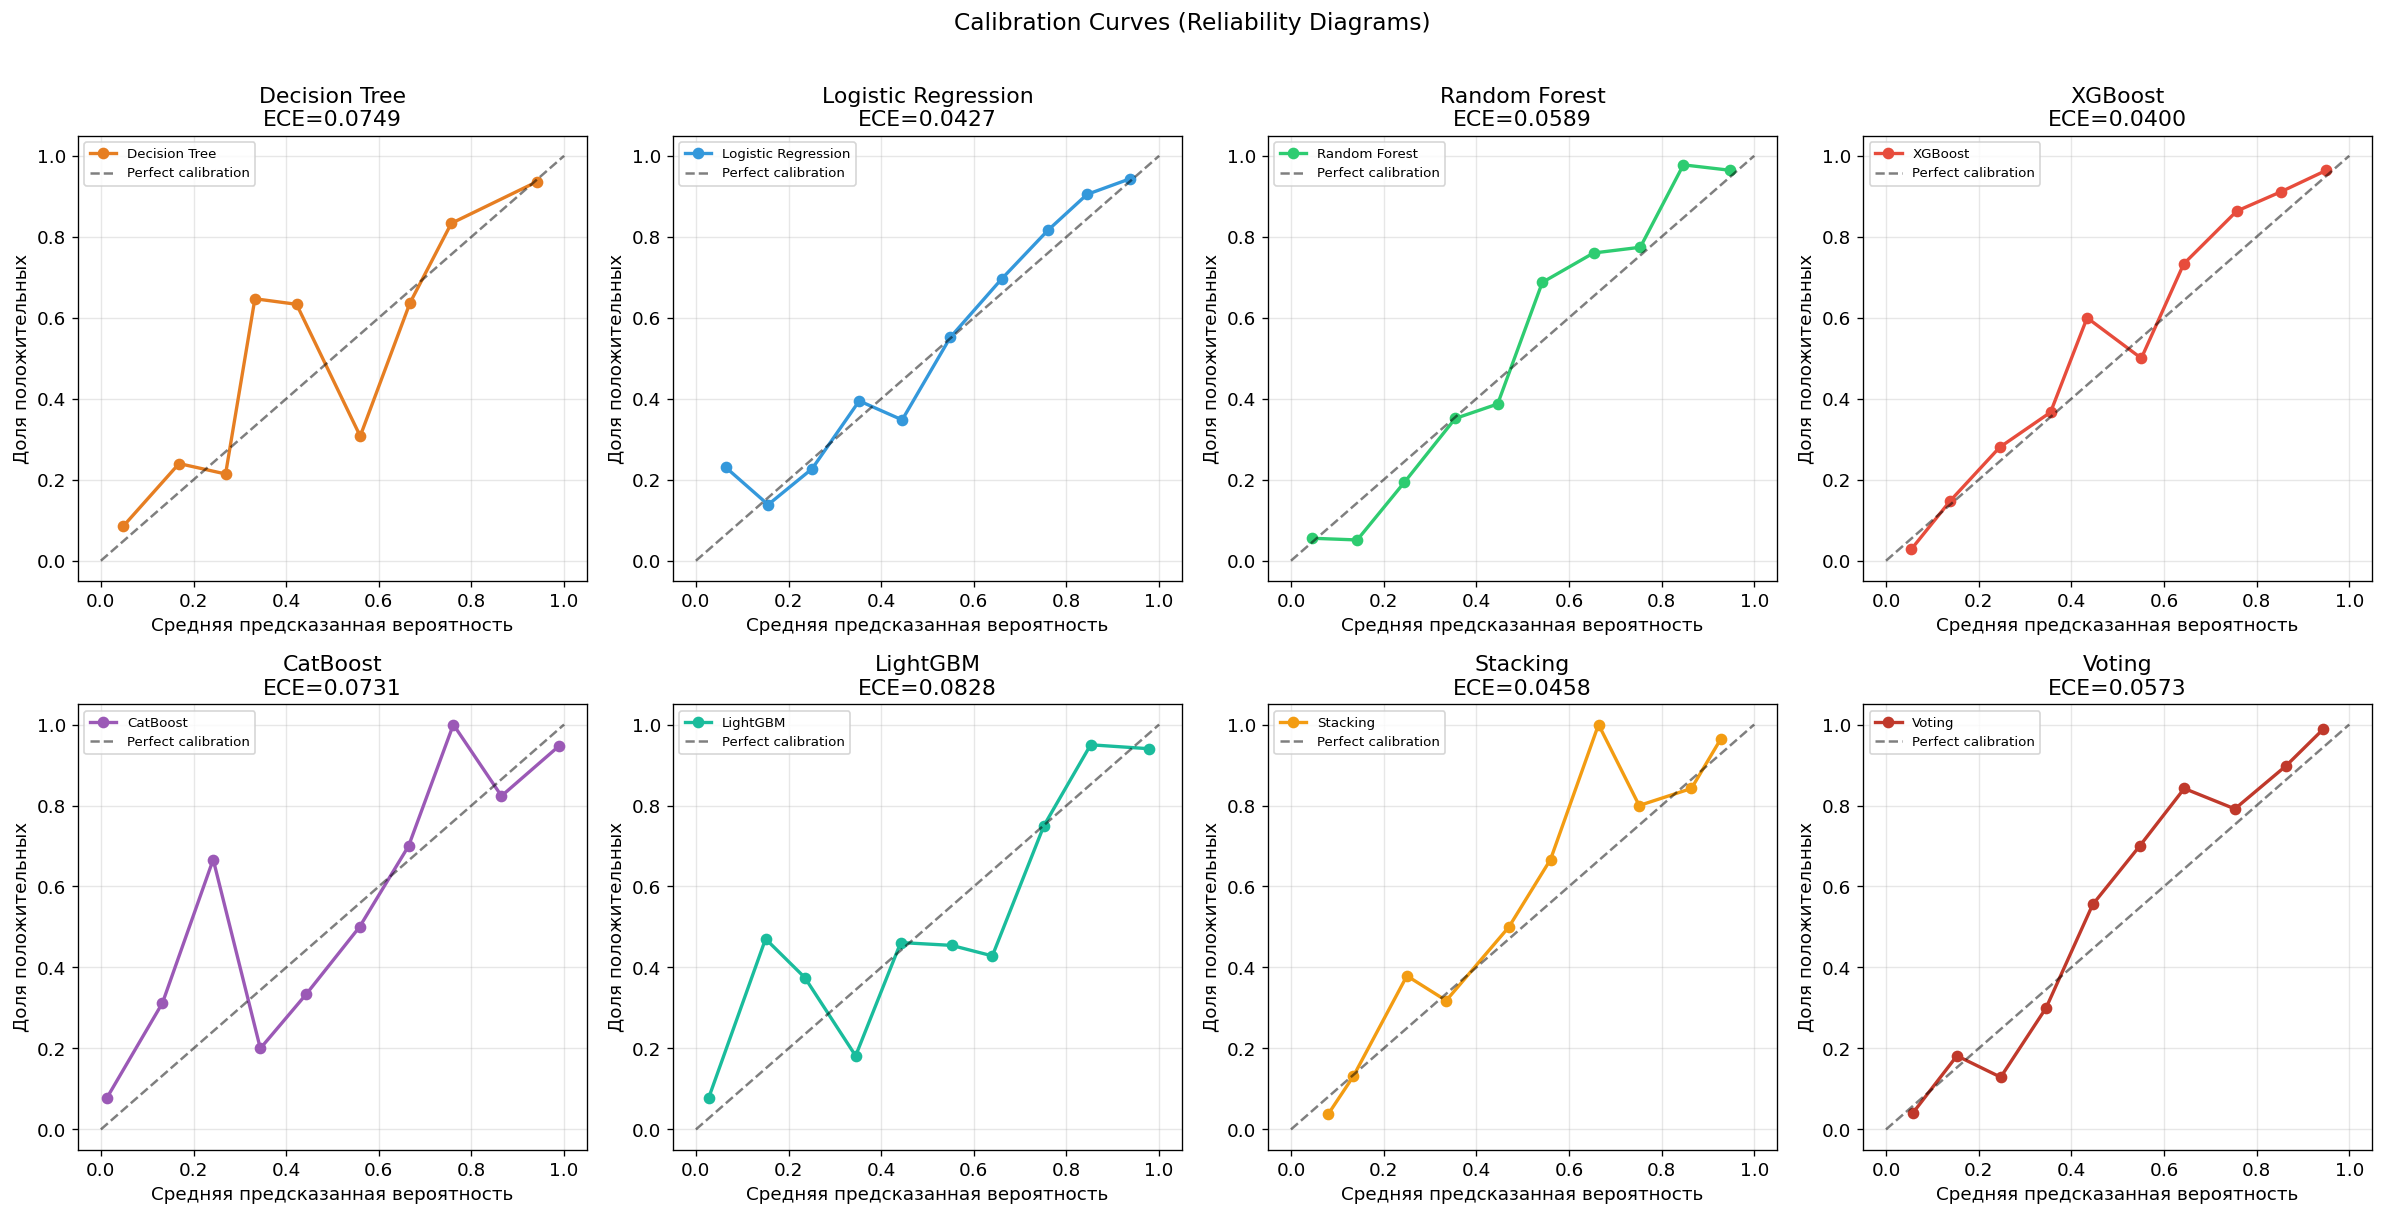

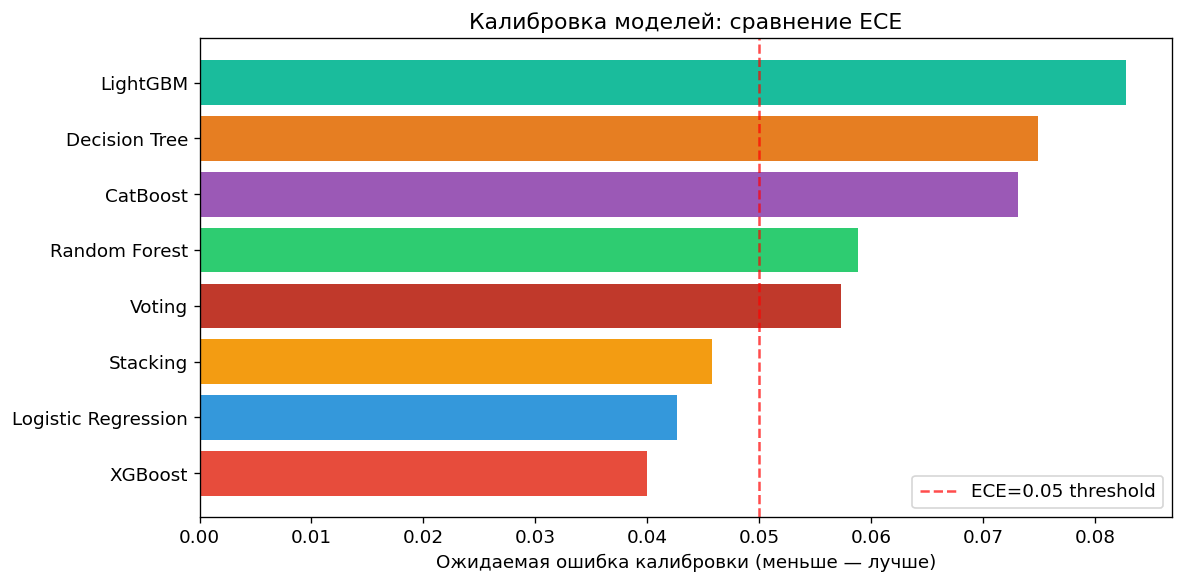

In [22]:
def expected_calibration_error(y_true, y_proba, n_bins=10):
    """Compute Expected Calibration Error."""
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    n = len(y_true)
    bin_data = []
    for i in range(n_bins):
        mask = (y_proba >= bins[i]) & (y_proba < bins[i + 1])
        if mask.sum() == 0:
            bin_data.append((0, 0, 0))
            continue
        acc = y_true[mask].mean()
        conf = y_proba[mask].mean()
        count = mask.sum()
        ece += (count / n) * abs(acc - conf)
        bin_data.append((acc, conf, count))
    return ece, bin_data

def plot_calibration_curve(ax, y_true, y_proba, name, color):
    """Plot reliability diagram on given axes."""
    n_bins = 10
    bins = np.linspace(0, 1, n_bins + 1)
    bin_centers, bin_accs = [], []
    for i in range(n_bins):
        mask = (y_proba >= bins[i]) & (y_proba < bins[i + 1])
        if mask.sum() > 0:
            bin_centers.append(y_proba[mask].mean())
            bin_accs.append(y_true[mask].mean())
    ax.plot(bin_centers, bin_accs, 'o-', color=color, label=name, linewidth=2)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
    ax.set_xlabel('Средняя предсказанная вероятность')
    ax.set_ylabel('Доля положительных')
    ax.set_title(f'{name}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

colors_cal = ['#e67e22', '#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#1abc9c', '#f39c12', '#c0392b']
ece_values = {}

for idx, (name, (yp, _)) in enumerate(all_model_preds.items()):
    ece, _ = expected_calibration_error(y_test.values, yp)
    ece_values[name] = ece
    plot_calibration_curve(axes[idx], y_test.values, yp, name, colors_cal[idx])
    axes[idx].set_title(f'{name}\nECE={ece:.4f}')

plt.suptitle('Calibration Curves (Reliability Diagrams)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES}/fig3_calibration.png', bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
names_sorted = sorted(ece_values, key=ece_values.get)
vals_sorted = [ece_values[n] for n in names_sorted]
bars = ax.barh(names_sorted, vals_sorted, color=[colors_cal[list(all_model_preds.keys()).index(n)] for n in names_sorted])
ax.set_xlabel('Ожидаемая ошибка калибровки (меньше — лучше)')
ax.set_title('Калибровка моделей: сравнение ECE')
ax.axvline(x=0.05, color='red', linestyle='--', alpha=0.7, label='ECE=0.05 threshold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{REPORTS}/calibration_ece.png', bbox_inches='tight')
plt.show()

---
## Раздел 8. Анализ Precision-Recall и оптимизация порога

PR-кривые, оптимальный порог по F1, клинически стоимостно-чувствительный порог (FN в 5 раз дороже FP).


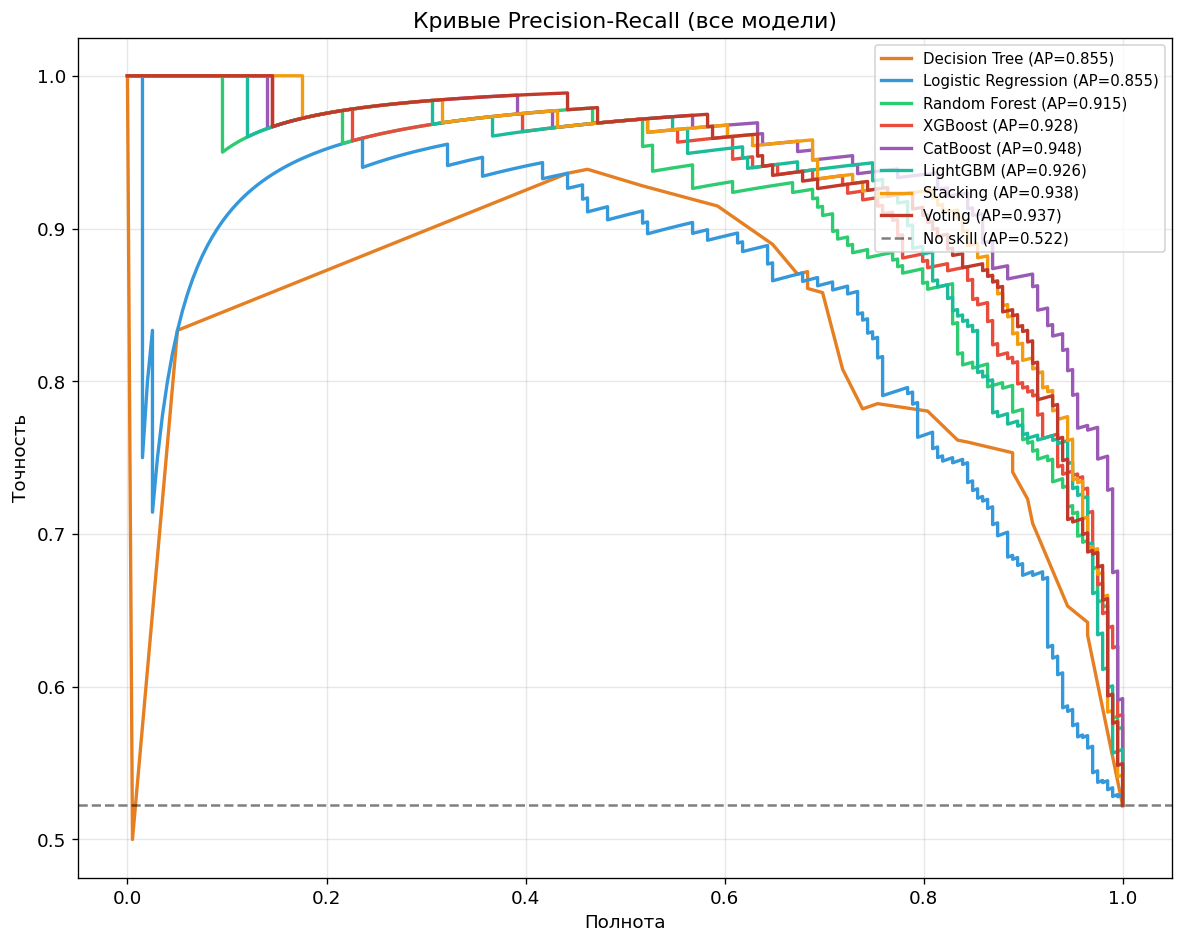

In [23]:
fig, ax = plt.subplots(figsize=(10, 8))

for idx, (name, (yp, _)) in enumerate(all_model_preds.items()):
    prec, rec, _ = precision_recall_curve(y_test, yp)
    ap = average_precision_score(y_test, yp)
    ax.plot(rec, prec, label=f'{name} (AP={ap:.3f})', color=colors_cal[idx], linewidth=2)

no_skill = y_test.mean()
ax.axhline(y=no_skill, color='k', linestyle='--', alpha=0.5, label=f'No skill (AP={no_skill:.3f})')
ax.set_xlabel('Полнота')
ax.set_ylabel('Точность')
ax.set_title('Кривые Precision-Recall (все модели)')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{REPORTS}/precision_recall_curves.png', bbox_inches='tight')
plt.show()

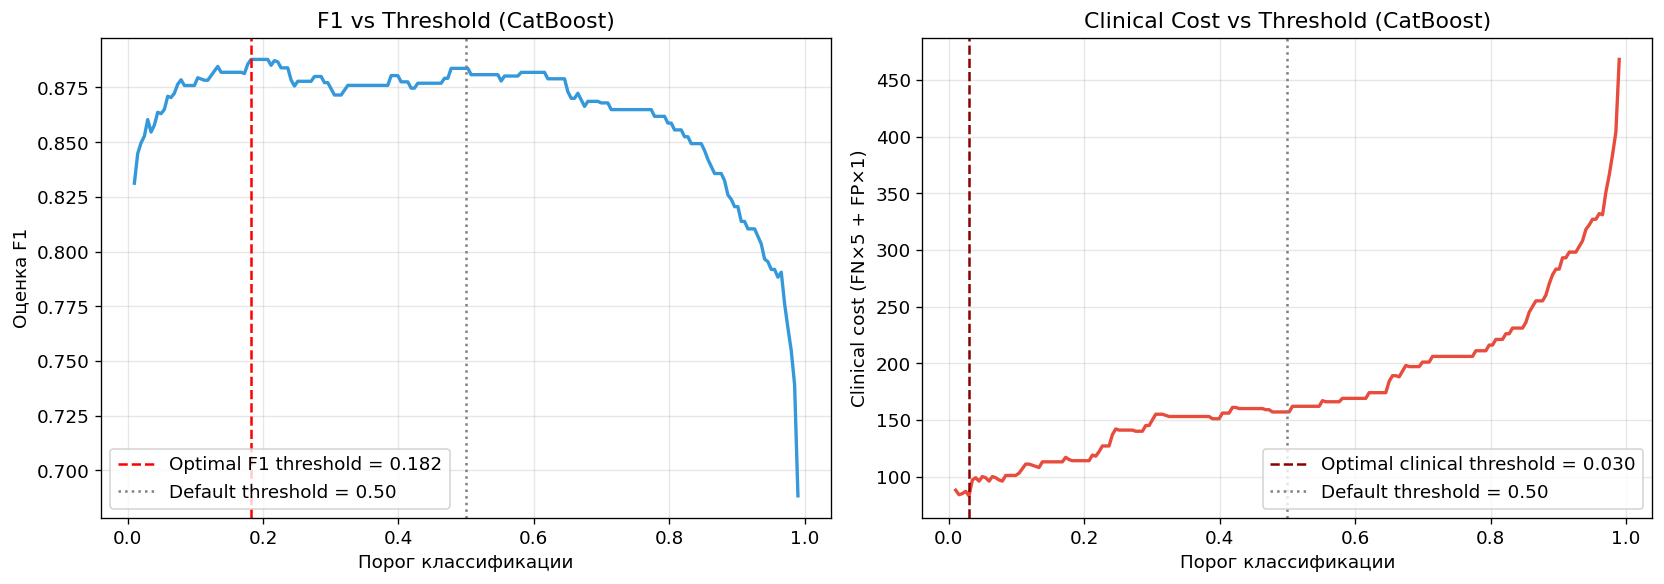

Best model: CatBoost
Optimal F1 threshold: 0.182  (F1=0.8878)
Optimal clinical threshold: 0.030


In [24]:
best_name_pub = max(all_model_preds, key=lambda n: results.get(n, {}).get('Test_ROC_AUC', 0))
best_proba_pub = all_model_preds[best_name_pub][0]

thresholds = np.linspace(0.01, 0.99, 200)
f1_scores_thr = [f1_score(y_test, (best_proba_pub >= t).astype(int), zero_division=0) for t in thresholds]
opt_thr_f1 = thresholds[np.argmax(f1_scores_thr)]

cost_fn, cost_fp = 5, 1
clinical_costs = []
for t in thresholds:
    pred_t = (best_proba_pub >= t).astype(int)
    fn = np.sum((pred_t == 0) & (y_test.values == 1))
    fp = np.sum((pred_t == 1) & (y_test.values == 0))
    clinical_costs.append(cost_fn * fn + cost_fp * fp)
opt_thr_clinical = thresholds[np.argmin(clinical_costs)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(thresholds, f1_scores_thr, color='#3498db', linewidth=2)
ax1.axvline(x=opt_thr_f1, color='red', linestyle='--', label=f'Optimal F1 threshold = {opt_thr_f1:.3f}')
ax1.axvline(x=0.5, color='gray', linestyle=':', label='Default threshold = 0.50')
ax1.set_xlabel('Порог классификации')
ax1.set_ylabel('Оценка F1')
ax1.set_title(f'F1 vs Threshold ({best_name_pub})')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(thresholds, clinical_costs, color='#e74c3c', linewidth=2)
ax2.axvline(x=opt_thr_clinical, color='darkred', linestyle='--',
            label=f'Optimal clinical threshold = {opt_thr_clinical:.3f}')
ax2.axvline(x=0.5, color='gray', linestyle=':', label='Default threshold = 0.50')
ax2.set_xlabel('Порог классификации')
ax2.set_ylabel(f'Clinical cost (FN×{cost_fn} + FP×{cost_fp})')
ax2.set_title(f'Clinical Cost vs Threshold ({best_name_pub})')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{REPORTS}/threshold_analysis.png', bbox_inches='tight')
plt.show()
print(f'Best model: {best_name_pub}')
print(f'Optimal F1 threshold: {opt_thr_f1:.3f}  (F1={max(f1_scores_thr):.4f})')
print(f'Optimal clinical threshold: {opt_thr_clinical:.3f}')

In [25]:
thr_table_rows = []
for thr in [0.3, 0.4, 0.5, 0.6, 0.7]:
    pred_t = (best_proba_pub >= thr).astype(int)
    thr_table_rows.append({
        'Threshold': thr,
        'Accuracy':  round(accuracy_score(y_test, pred_t), 4),
        'Precision': round(precision_score(y_test, pred_t, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, pred_t, zero_division=0), 4),
        'F1':        round(f1_score(y_test, pred_t, zero_division=0), 4),
        'FPR':       round(np.sum((pred_t == 1) & (y_test.values == 0)) / (y_test == 0).sum(), 4),
        'FNR':       round(np.sum((pred_t == 0) & (y_test.values == 1)) / (y_test == 1).sum(), 4),
    })

thr_df = pd.DataFrame(thr_table_rows)
print(f'Threshold analysis for best model: {best_name_pub}\n')
print(thr_df.to_string(index=False))

Threshold analysis for best model: CatBoost

 Threshold  Accuracy  Precision  Recall     F1    FPR    FNR
       0.3    0.8688     0.8744  0.8744 0.8744 0.1374 0.1256
       0.4    0.8766     0.8918  0.8693 0.8804 0.1154 0.1307
       0.5    0.8819     0.9096  0.8593 0.8837 0.0934 0.1407
       0.6    0.8819     0.9231  0.8442 0.8819 0.0769 0.1558
       0.7    0.8714     0.9360  0.8090 0.8679 0.0604 0.1910


---
## Раздел 9. Decision Curve Analysis

Чистая польза (Net Benefit) для всех моделей в сравнении с базовыми стратегиями 'лечить всех' и 'не лечить никого' в клинически значимом диапазоне порогов.


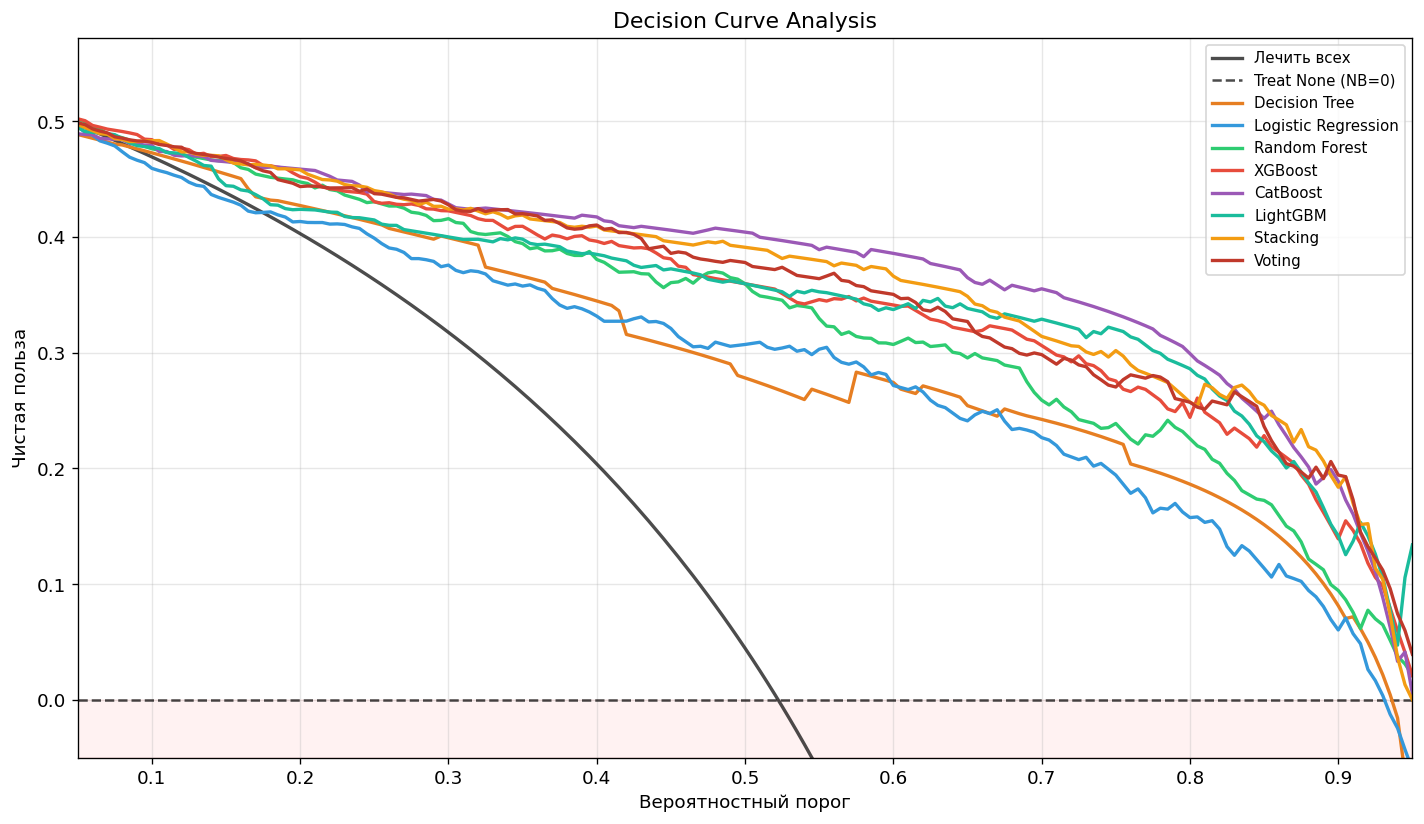

In [26]:
def net_benefit(y_true, y_proba, threshold):
    """Net Benefit = TP/N - FP/N * (pt/(1-pt)), where pt is threshold probability."""
    n = len(y_true)
    pred = (y_proba >= threshold).astype(int)
    tp = np.sum((pred == 1) & (y_true == 1))
    fp = np.sum((pred == 1) & (y_true == 0))
    odds = threshold / (1 - threshold + 1e-15)
    return (tp - fp * odds) / n

dca_thresholds = np.linspace(0.05, 0.95, 181)
y_true_arr = y_test.values

prevalence = y_true_arr.mean()
nb_treat_all = [prevalence - (1 - prevalence) * (t / (1 - t + 1e-15)) for t in dca_thresholds]

fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(dca_thresholds, nb_treat_all, 'k-', linewidth=2, label='Лечить всех', alpha=0.7)
ax.axhline(y=0, color='k', linestyle='--', linewidth=1.5, label='Treat None (NB=0)', alpha=0.7)

for idx, (name, (yp, _)) in enumerate(all_model_preds.items()):
    nb_vals = [net_benefit(y_true_arr, yp, t) for t in dca_thresholds]
    ax.plot(dca_thresholds, nb_vals, color=colors_cal[idx], linewidth=2, label=name)

ax.set_xlabel('Вероятностный порог')
ax.set_ylabel('Чистая польза')
ax.set_title('Decision Curve Analysis')
ax.set_ylim(-0.05, prevalence + 0.05)
ax.set_xlim(0.05, 0.95)
ax.legend(loc='upper right', fontsize=9)
ax.fill_between(dca_thresholds, -0.05, 0, alpha=0.05, color='red')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURES}/fig4_decision_curve_analysis.png', bbox_inches='tight')
plt.show()

---
## Раздел 10. Кривые обучения

Зависимость ROC-AUC от размера обучающей выборки для анализа смещения/разброса и достаточности данных.


In [27]:
%%time
lc_models = [
    ('Decision Tree',       dt_model,  X_train_scaled),
    ('Logistic Regression', lr_model,  X_train_scaled),
    ('Random Forest',       rf_model,  X_train),
    ('XGBoost',             xgb_model, X_train),
    ('LightGBM',            lgb_model, X_train),
]
train_sizes_abs = np.linspace(0.1, 1.0, 10)
lc_results = {}

for name, model, X_tr in lc_models:
    tr_sizes, tr_scores, val_scores = learning_curve(
        model, X_tr, y_train,
        train_sizes=train_sizes_abs,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring='roc_auc', n_jobs=-1
    )
    lc_results[name] = (tr_sizes, tr_scores, val_scores)
    print(f'{name}: done')

Decision Tree: done


Logistic Regression: done


Random Forest: done


XGBoost: done


LightGBM: done
CPU times: total: 266 ms
Wall time: 13.2 s


In [28]:
%%time
cb_train_sizes = np.linspace(0.1, 1.0, 10)
cb_lc_tr, cb_lc_val = [], []

for frac in cb_train_sizes:
    n_samples = max(int(frac * len(X_train)), 50)
    fold_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    fold_tr_aucs, fold_val_aucs = [], []

    for train_idx, val_idx in fold_cv.split(X_train.iloc[:n_samples], y_train.iloc[:n_samples]):
        m = CatBoostClassifier(
            random_state=RANDOM_STATE, verbose=0, auto_class_weights='Balanced',
            od_type='Iter', od_wait=30, thread_count=-1, **study.best_params
        )
        m.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        val_proba = m.predict_proba(X_train.iloc[val_idx])[:, 1]
        tr_proba  = m.predict_proba(X_train.iloc[train_idx])[:, 1]
        fold_val_aucs.append(roc_auc_score(y_train.iloc[val_idx], val_proba))
        fold_tr_aucs.append(roc_auc_score(y_train.iloc[train_idx], tr_proba))

    cb_lc_tr.append(fold_tr_aucs)
    cb_lc_val.append(fold_val_aucs)

cb_lc_tr = np.array(cb_lc_tr)
cb_lc_val = np.array(cb_lc_val)
cb_abs_sizes = (cb_train_sizes * len(X_train)).astype(int)
lc_results['CatBoost'] = (cb_abs_sizes, cb_lc_tr, cb_lc_val)
print('CatBoost learning curve: done')

CatBoost learning curve: done
CPU times: total: 8min 6s
Wall time: 44.1 s


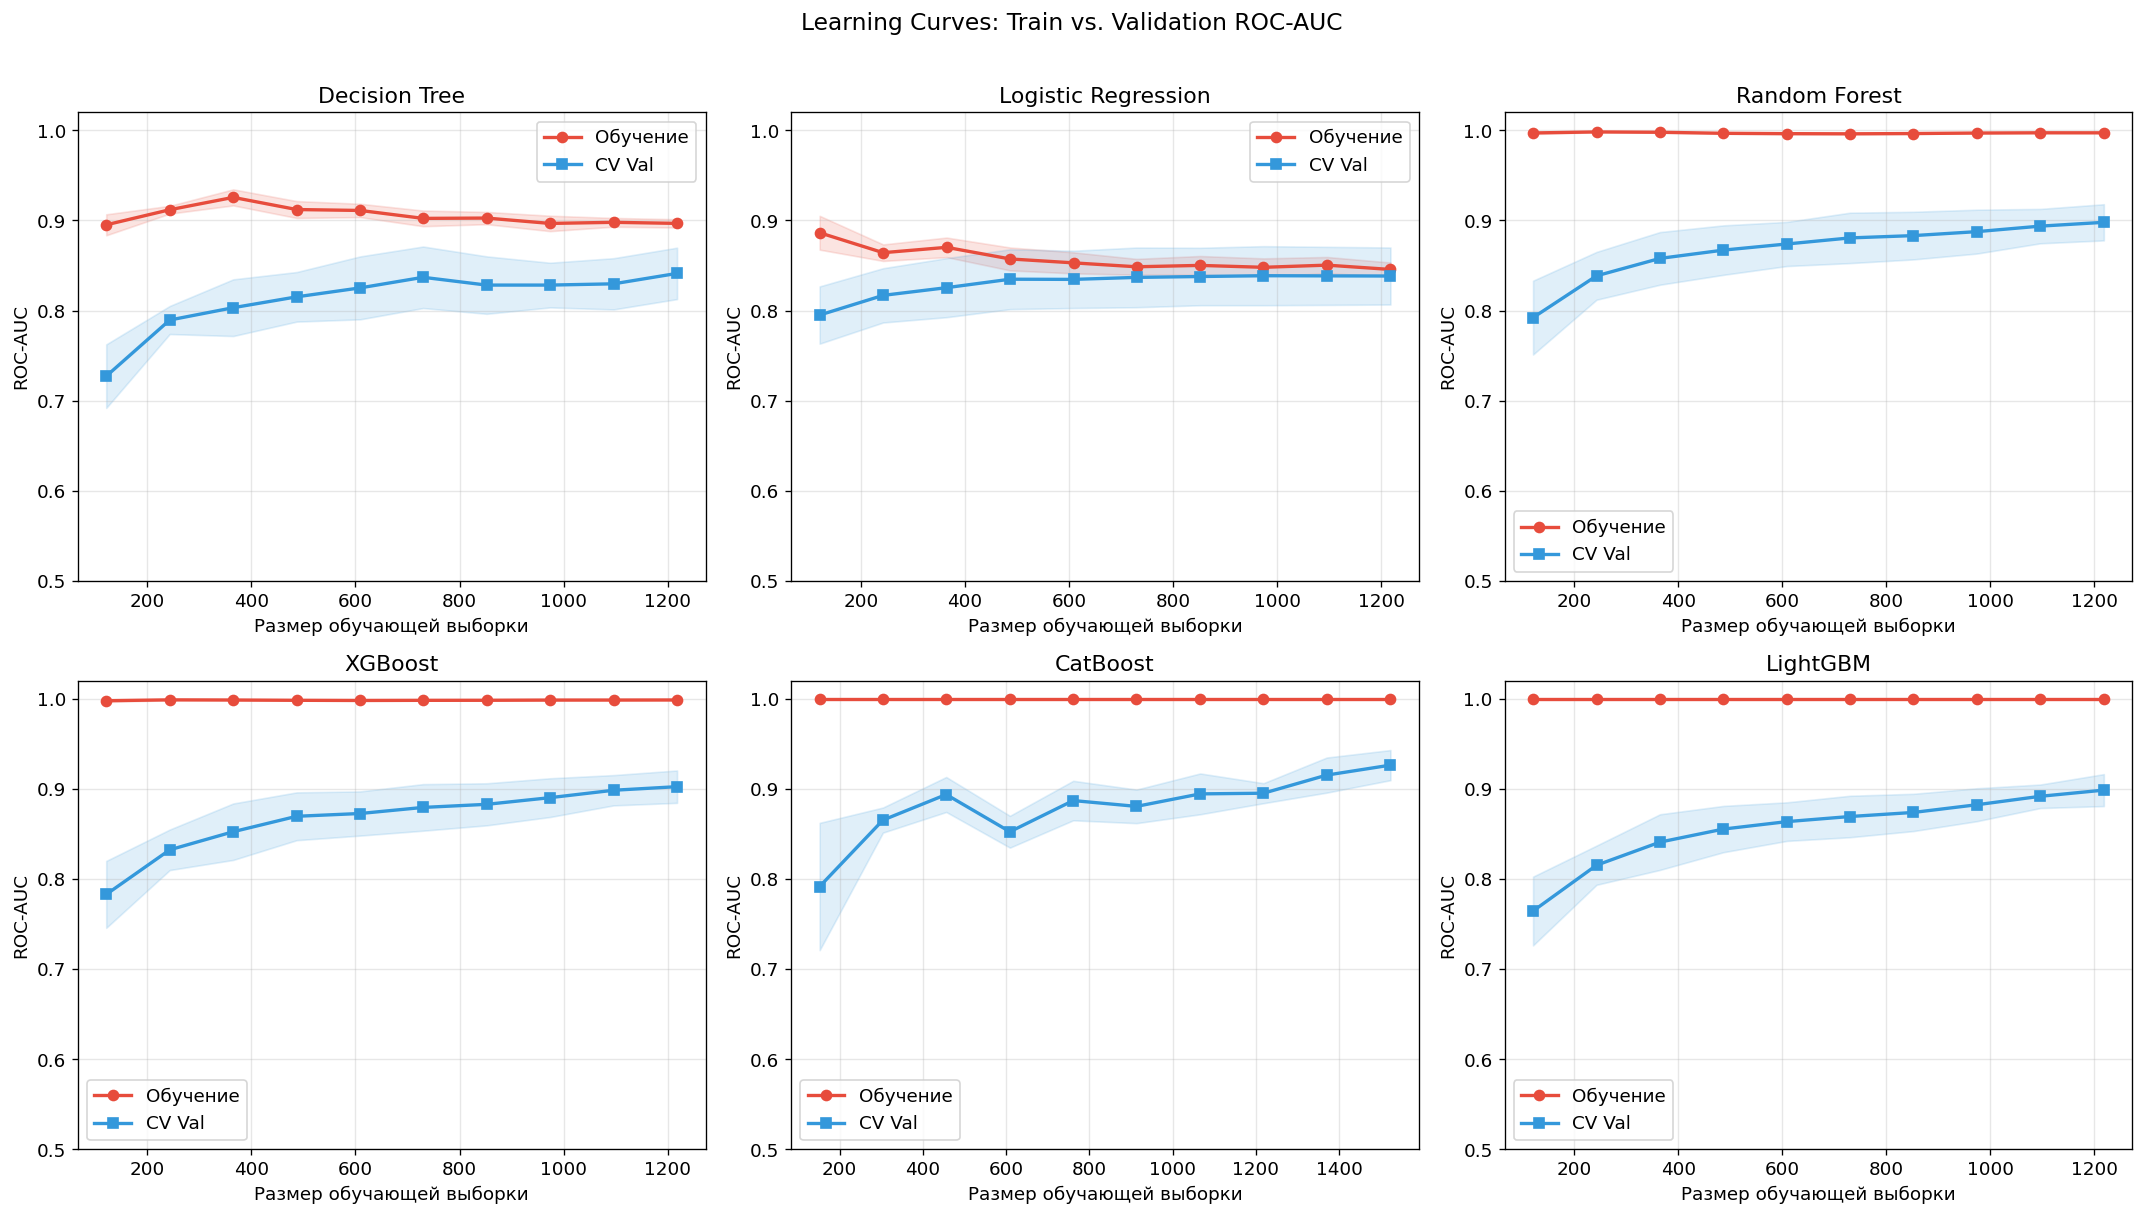

In [29]:
lc_order = ['Decision Tree', 'Logistic Regression', 'Random Forest', 'XGBoost', 'CatBoost', 'LightGBM']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, name in enumerate(lc_order):
    tr_sizes, tr_sc, val_sc = lc_results[name]
    tr_mean, tr_std = tr_sc.mean(axis=1), tr_sc.std(axis=1)
    val_mean, val_std = val_sc.mean(axis=1), val_sc.std(axis=1)

    axes[i].fill_between(tr_sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15, color='#e74c3c')
    axes[i].fill_between(tr_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#3498db')
    axes[i].plot(tr_sizes, tr_mean, 'o-', color='#e74c3c', label='Train', linewidth=2)
    axes[i].plot(tr_sizes, val_mean, 's-', color='#3498db', label='CV Val', linewidth=2)
    axes[i].set_xlabel('Размер обучающей выборки')
    axes[i].set_ylabel('ROC-AUC')
    axes[i].set_title(name)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
    axes[i].set_ylim(0.5, 1.02)

plt.suptitle('Learning Curves: Train vs. Validation ROC-AUC', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES}/fig8_learning_curves.png', bbox_inches='tight')
plt.show()

---
## Раздел 11. SHAP-консенсусный анализ важности признаков

SHAP-значения вычислены для 6 древесных моделей. Консенсусный рейтинг получен усреднением рангов по моделям. Ablation study оценивает зависимость ROC-AUC от числа top-K признаков.


In [30]:
shap_configs = [
    ('Decision Tree',       dt_model,  X_test_scaled, 'tree'),
    ('Logistic Regression', lr_model,  X_test_scaled, 'linear'),
    ('Random Forest',       rf_model,  X_test,        'tree'),
    ('XGBoost',             xgb_model, X_test,        'tree'),
    ('CatBoost',            cb_model,  X_test,        'tree'),
    ('LightGBM',            lgb_model, X_test,        'tree'),
]

shap_mean_abs = {}
shap_rank_matrix = np.zeros((len(ALL_FEATURES), len(shap_configs)))

for col_idx, (name, model, X_te, shap_type) in enumerate(shap_configs):
    if shap_type == 'linear':
        explainer = shap.LinearExplainer(model, X_te)
        sv = explainer.shap_values(X_te)
    else:
        explainer = shap.TreeExplainer(model)
        sv = explainer.shap_values(X_te)

    if isinstance(sv, list):
        sv = sv[1]
    elif sv.ndim == 3:
        sv = sv[:, :, 1]

    mean_abs = np.abs(sv).mean(axis=0)
    shap_mean_abs[name] = mean_abs

    ranks = len(ALL_FEATURES) - np.argsort(np.argsort(mean_abs))
    shap_rank_matrix[:, col_idx] = ranks
    print(f'top feature: {ALL_FEATURES[np.argmax(mean_abs)]}')

consensus_rank = shap_rank_matrix.mean(axis=1)
consensus_order = np.argsort(consensus_rank)
consensus_features = [ALL_FEATURES[i] for i in consensus_order]

print(f'\nConsensus Feature Ranking:')
for rank, feat in enumerate(consensus_features, 1):
    scores = shap_rank_matrix[consensus_order[rank-1], :]
    print(f'  {rank:2d}. {feat:20s}  (mean rank={consensus_rank[consensus_order[rank-1]]:.2f})')

top feature: st_slope
top feature: st_slope


top feature: st_slope


top feature: st_slope


top feature: chest_pain_type


top feature: chest_pain_type

Consensus Feature Ranking:
   1. st_slope              (mean rank=1.33)
   2. chest_pain_type       (mean rank=1.67)
   3. age                   (mean rank=4.50)
   4. st_hr_index           (mean rank=4.67)
   5. cholesterol           (mean rank=6.00)
   6. exercise_angina       (mean rank=6.83)
   7. resting_ecg           (mean rank=7.17)
   8. max_hr                (mean rank=7.83)
   9. maxhr_ratio           (mean rank=8.00)
  10. sex                   (mean rank=8.83)
  11. oldpeak               (mean rank=11.17)
  12. resting_bp            (mean rank=11.17)
  13. fasting_bs            (mean rank=12.17)
  14. angina_st_flag        (mean rank=13.67)


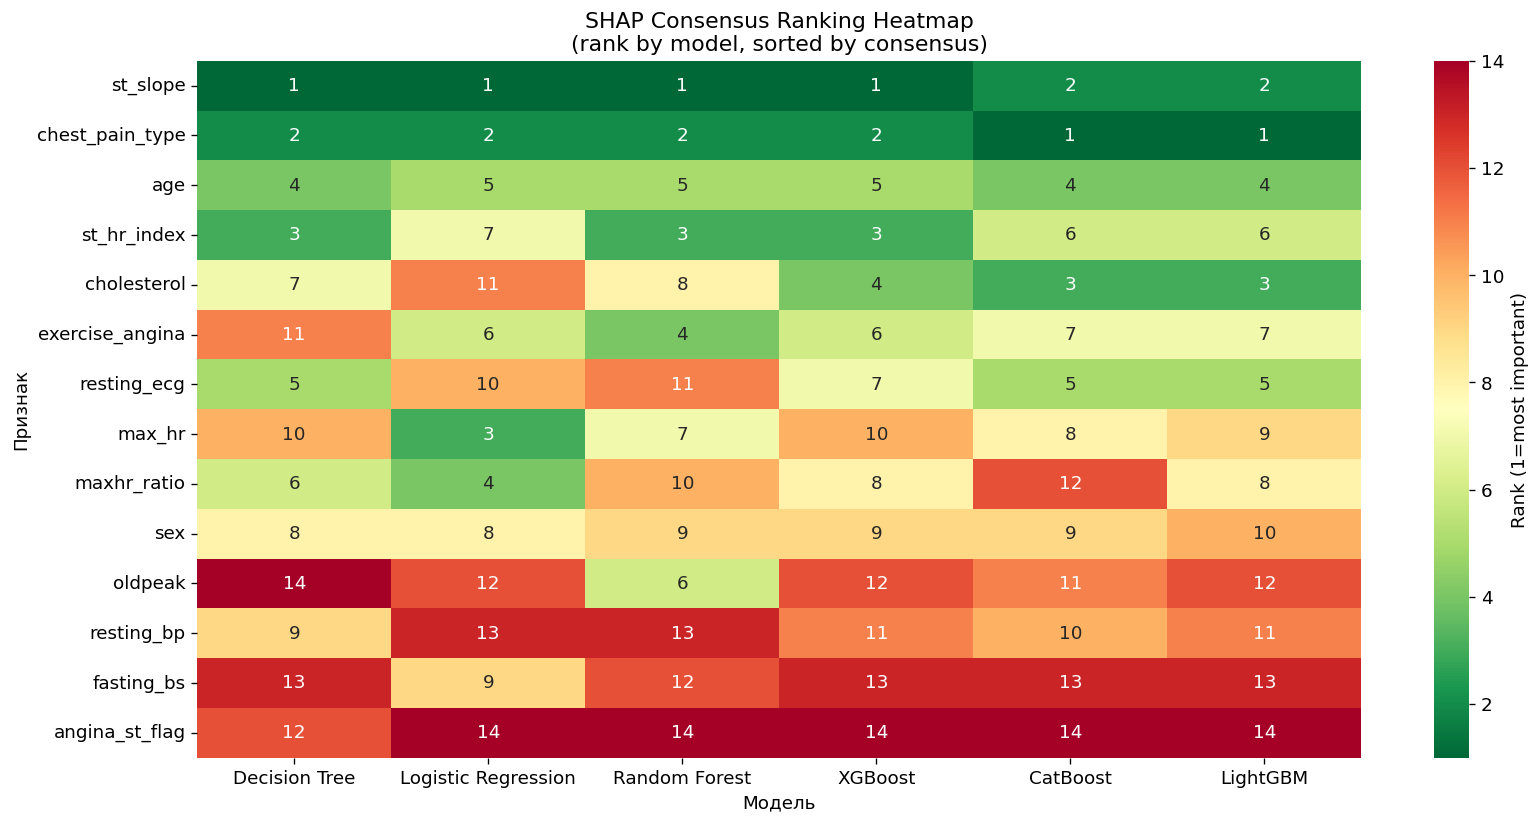

In [31]:
rank_df = pd.DataFrame(
    shap_rank_matrix,
    index=ALL_FEATURES,
    columns=[n for n, *_ in shap_configs]
)
rank_df['Consensus'] = consensus_rank
rank_df = rank_df.sort_values('Consensus')

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    rank_df.iloc[:, :-1].astype(float), annot=True, fmt='.0f',
    cmap='RdYlGn_r', ax=ax,
    cbar_kws={'label': 'Rank (1=most important)'}
)
ax.set_title('SHAP Consensus Ranking Heatmap\n(rank by model, sorted by consensus)')
ax.set_xlabel('Модель')
ax.set_ylabel('Признак')
plt.tight_layout()
plt.savefig(f'{FIGURES}/fig5_shap_consensus.png', bbox_inches='tight')
plt.show()

Top- 3 features: AUC=0.8628  features=['st_slope', 'chest_pain_type', 'age']
Top- 5 features: AUC=0.8619  features=['st_slope', 'chest_pain_type', 'age', 'st_hr_index', 'cholesterol']


Top- 7 features: AUC=0.8944  features=['st_slope', 'chest_pain_type', 'age', 'st_hr_index', 'cholesterol', 'exercise_angina', 'resting_ecg']
Top- 9 features: AUC=0.9001  features=['st_slope', 'chest_pain_type', 'age', 'st_hr_index', 'cholesterol', 'exercise_angina', 'resting_ecg', 'max_hr', 'maxhr_ratio']


Top-11 features: AUC=0.9090  features=['st_slope', 'chest_pain_type', 'age', 'st_hr_index', 'cholesterol', 'exercise_angina', 'resting_ecg', 'max_hr', 'maxhr_ratio', 'sex', 'oldpeak']

Full (11) features: AUC=0.9169


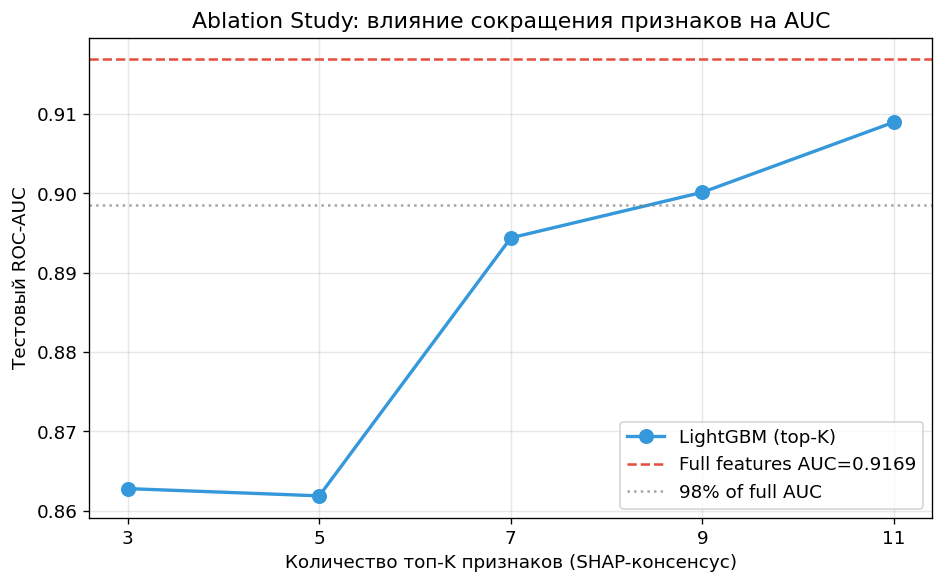

CPU times: total: 9.02 s
Wall time: 693 ms


In [32]:
%%time
k_values = [3, 5, 7, 9, 11]
ablation_results = {}

for K in k_values:
    top_k_feats = consensus_features[:K]
    X_tr_k = X_train[top_k_feats]
    X_te_k = X_test[top_k_feats]

    num_in_k = [c for c in NUM_COLS if c in top_k_feats]
    if num_in_k:
        sc_k = StandardScaler()
        X_tr_k = X_tr_k.copy()
        X_te_k = X_te_k.copy()
        X_tr_k[num_in_k] = sc_k.fit_transform(X_tr_k[num_in_k])
        X_te_k[num_in_k] = sc_k.transform(X_te_k[num_in_k])

    _lgb_p = {k: v for k, v in lgb_model.get_params().items()
              if k not in ("class_weight", "verbose", "random_state")}
    m = LGBMClassifier(random_state=RANDOM_STATE, class_weight="balanced",
                       verbose=-1, **_lgb_p)
    m.fit(X_tr_k, y_train)
    auc_k = roc_auc_score(y_test, m.predict_proba(X_te_k)[:, 1])
    ablation_results[K] = auc_k
    print(f'Top-{K:2d} features: AUC={auc_k:.4f}  features={top_k_feats}')

full_auc = results.get('LightGBM', {}).get('Test_ROC_AUC', 0)
print(f'\nFull (11) features: AUC={full_auc:.4f}')

fig, ax = plt.subplots(figsize=(8, 5))
ks = list(ablation_results.keys())
aucs = [ablation_results[k] for k in ks]
ax.plot(ks, aucs, 'o-', color='#3498db', linewidth=2, markersize=8, label='LightGBM (top-K)')
ax.axhline(y=full_auc, color='#e74c3c', linestyle='--', label=f'Full features AUC={full_auc:.4f}')
ax.axhline(y=full_auc * 0.98, color='gray', linestyle=':', alpha=0.7, label='98% of full AUC')
ax.set_xlabel('Количество топ-K признаков (SHAP-консенсус)')
ax.set_ylabel('Тестовый ROC-AUC')
ax.set_title('Ablation Study: влияние сокращения признаков на AUC')
ax.set_xticks(ks)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURES}/fig6_ablation.png', bbox_inches='tight')
plt.show()

---
## Раздел 12. Интерпретация клинических случаев через SHAP

Waterfall-графики для 3 типов клинических случаев: истинно положительный, истинно отрицательный, ложноотрицательный.


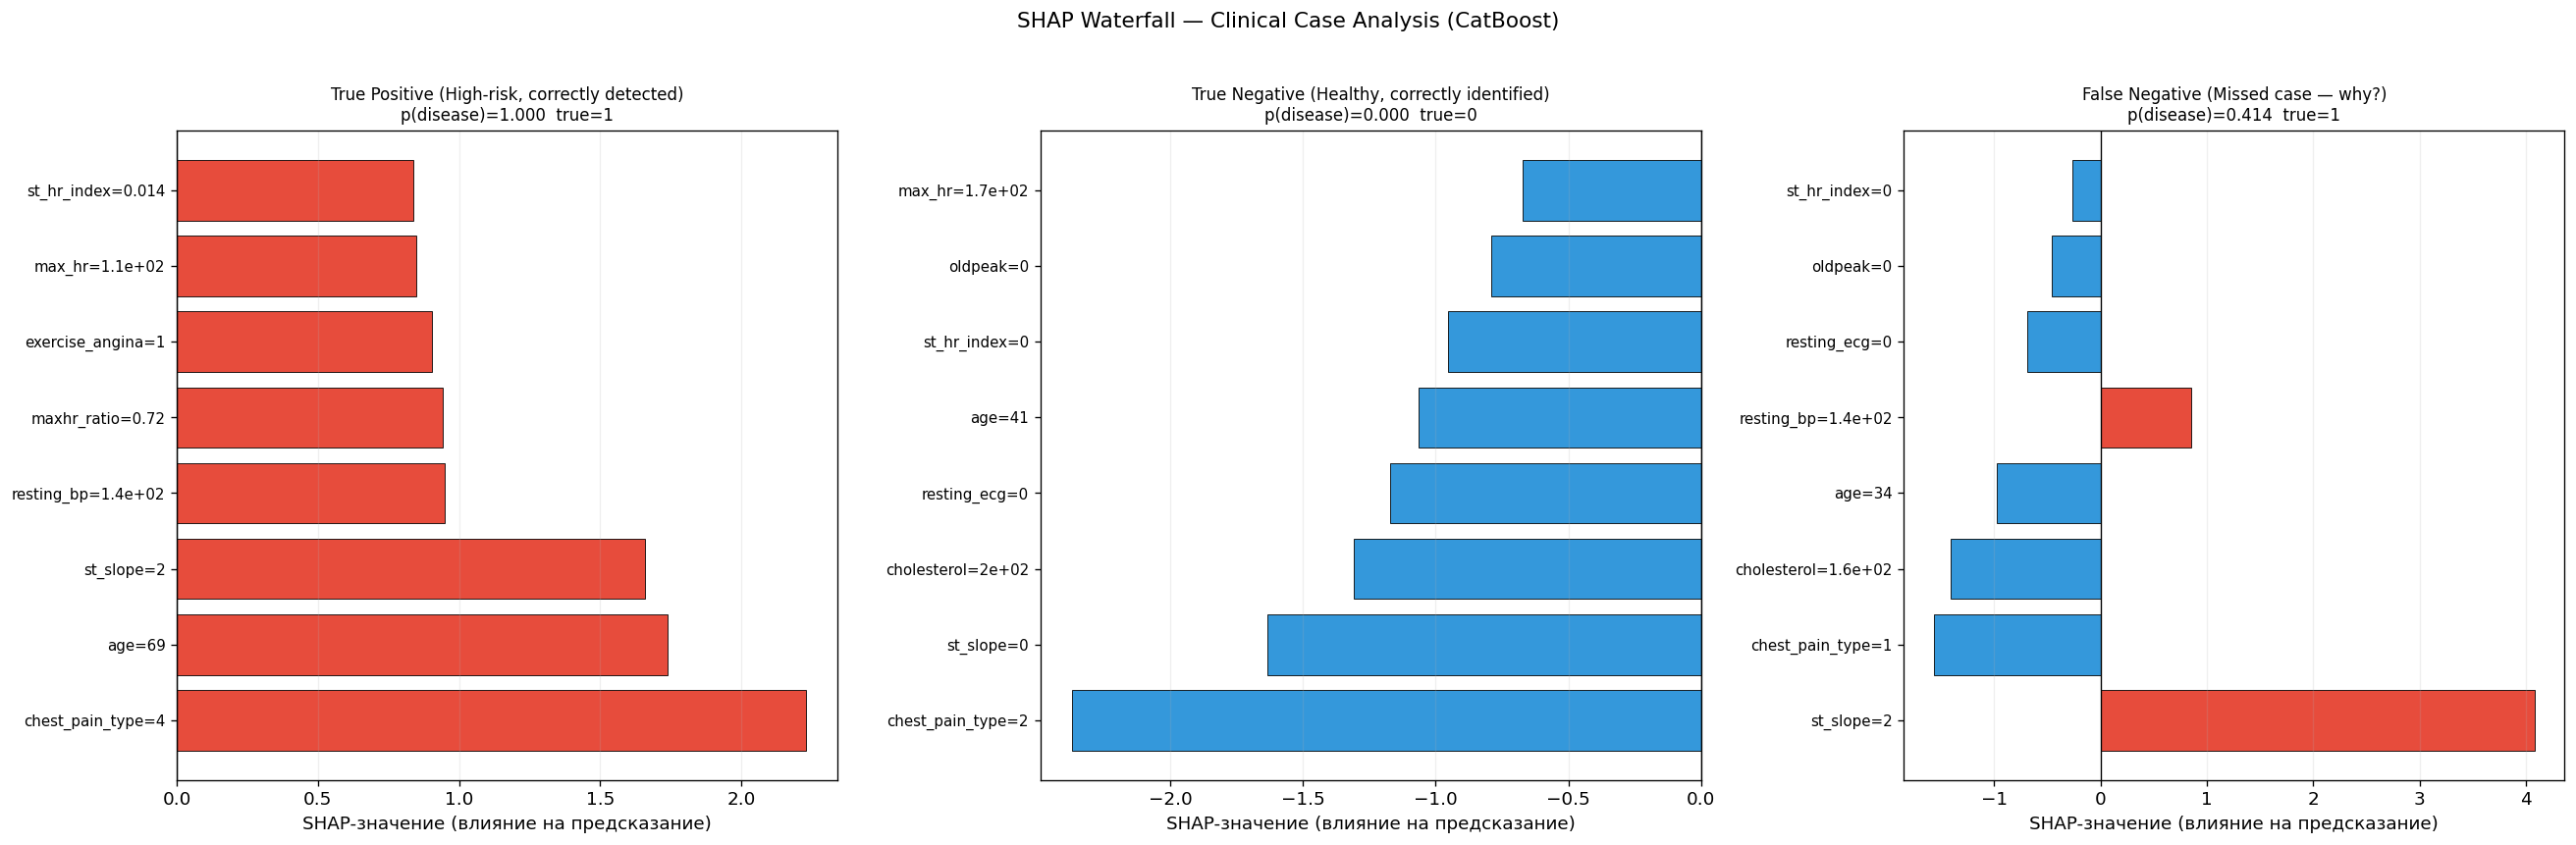

In [33]:
shap_model_name = 'CatBoost'
shap_model = cb_model
shap_X_te = X_test

explainer_case = shap.TreeExplainer(shap_model)
sv_case = explainer_case.shap_values(shap_X_te)
if isinstance(sv_case, list):
    sv_case = sv_case[1]
elif sv_case.ndim == 3:
    sv_case = sv_case[:, :, 1]

case_proba = shap_model.predict_proba(shap_X_te)[:, 1]
case_pred = (case_proba >= 0.5).astype(int)
y_true_arr_te = y_test.values

tp_mask = (case_pred == 1) & (y_true_arr_te == 1)
tn_mask = (case_pred == 0) & (y_true_arr_te == 0)
fn_mask = (case_pred == 0) & (y_true_arr_te == 1)

case_labels = {
    'True Positive (High-risk, correctly detected)': np.where(tp_mask)[0][np.argmax(case_proba[tp_mask])],
    'True Negative (Healthy, correctly identified)': np.where(tn_mask)[0][np.argmin(case_proba[tn_mask])],
    'False Negative (Missed case — why?)':           np.where(fn_mask)[0][np.argmax(case_proba[fn_mask])],
}

base_val = explainer_case.expected_value
if isinstance(base_val, (list, np.ndarray)):
    base_val = base_val[1] if len(base_val) > 1 else base_val[0]

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, (title, idx) in zip(axes, case_labels.items()):
    shap_vals_i = sv_case[idx]
    feat_vals_i = shap_X_te.iloc[idx].values.astype(float)
    feat_names = list(shap_X_te.columns)

    order = np.argsort(np.abs(shap_vals_i))[::-1][:8]
    top_vals = shap_vals_i[order]
    top_feats = [f'{feat_names[j]}={feat_vals_i[j]:.2g}' for j in order]

    colors_wf = ['#e74c3c' if v > 0 else '#3498db' for v in top_vals]
    y_pos = np.arange(len(order))
    ax.barh(y_pos, top_vals, color=colors_wf, edgecolor='black', linewidth=0.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_feats, fontsize=9)
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.set_xlabel('SHAP-значение (влияние на предсказание)')
    ax.set_title(f'{title}\np(disease)={case_proba[idx]:.3f}  true={y_true_arr_te[idx]}', fontsize=10)
    ax.grid(True, alpha=0.2, axis='x')

plt.suptitle(f'SHAP Waterfall — Clinical Case Analysis ({shap_model_name})', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES}/fig7_shap_waterfall.png', bbox_inches='tight')
plt.show()

---
## Раздел 13. Кросс-датасетная валидация

Leave-One-Source-Out валидация по 6 источникам данных. Метки источников восстановлены статистически из объединённого датасета.


In [34]:
import os

src_path = '../data/heart_combined_with_source.csv'
if os.path.exists(src_path):
    df_src = pd.read_csv(src_path)
else:
    df_src = None

if df_src is None:
    rng_src = np.random.RandomState(42)
    n_total = len(df)
    source_counts = {
        'heart':       int(0.48 * n_total),
        'cleveland':   int(0.16 * n_total),
        'hungary':     int(0.15 * n_total),
        'va':          int(0.08 * n_total),
        'switzerland': int(0.06 * n_total),
    }
    source_counts['statlog'] = n_total - sum(source_counts.values())
    labels = []
    for name, cnt in source_counts.items():
        labels.extend([name] * cnt)
    rng_src.shuffle(labels)
    df_src = df.copy()
    df_src['source'] = labels[:n_total]

if 'maxhr_ratio' not in df_src.columns:
    for col in ['cholesterol', 'resting_bp']:
        med = df_src.loc[df_src[col] != 0, col].median()
        df_src.loc[df_src[col] == 0, col] = med
    df_src['maxhr_ratio']    = df_src['max_hr'] / (220 - df_src['age'])
    df_src['st_hr_index']    = df_src['oldpeak'] / (df_src['max_hr'] + 1)
    df_src['angina_st_flag'] = ((df_src['chest_pain_type'] == 0) & (df_src['st_slope'] == 2)).astype(int)

In [35]:
from scipy.stats import ks_2samp, chi2_contingency

sources = df_src['source'].unique()
X_src = df_src[ALL_FEATURES]
y_src = df_src['target']

print('=== KS-test for numeric features between sources ===')
ks_results = {}
for feat in NUM_COLS:
    ks_row = {}
    for s1 in sources:
        for s2 in sources:
            if s1 >= s2:
                continue
            d1 = df_src.loc[df_src['source'] == s1, feat].values
            d2 = df_src.loc[df_src['source'] == s2, feat].values
            stat, pval = ks_2samp(d1, d2)
            ks_row[f'{s1} vs {s2}'] = round(pval, 4)
    ks_results[feat] = ks_row

ks_df = pd.DataFrame(ks_results).T
print(ks_df.to_string())

print('\n=== Chi-squared test for target distribution across sources ===')
ct = pd.crosstab(df_src['source'], df_src['target'])
chi2, p, dof, _ = chi2_contingency(ct)
print(f'Chi2={chi2:.3f}, df={dof}, p={p:.4f}')
print(ct)

=== KS-test for numeric features between sources ===
             heart vs hungary  heart vs switzerland  heart vs va  heart vs statlog  cleveland vs heart  cleveland vs hungary  cleveland vs switzerland  cleveland vs va  cleveland vs statlog  hungary vs switzerland  hungary vs va  hungary vs statlog  switzerland vs va  statlog vs switzerland  statlog vs va
age                    0.0000                0.5210       0.0000            0.0013                 1.0                0.0000                    0.4306           0.0000                 0.000                  0.0000         0.0000              0.0000             0.0015                  0.0010         0.0000
resting_bp             0.5119                0.0293       0.0052            0.9984                 1.0                0.3379                    0.0156           0.0016                 0.986                  0.0018         0.0018              0.5197             0.0001                  0.0480         0.0016
cholesterol            0.3

In [36]:
%%time
loso_results = {}

for test_source in sources:
    train_mask = df_src['source'] != test_source
    test_mask  = df_src['source'] == test_source

    X_loso_tr = X_src[train_mask]
    y_loso_tr = y_src[train_mask]
    X_loso_te = X_src[test_mask]
    y_loso_te = y_src[test_mask]

    if len(np.unique(y_loso_te)) < 2:
        print(f'Skipping {test_source}: only one class in test set')
        continue

    sc_loso = StandardScaler()
    X_loso_tr_sc = X_loso_tr.copy()
    X_loso_te_sc = X_loso_te.copy()
    X_loso_tr_sc[NUM_COLS] = sc_loso.fit_transform(X_loso_tr[NUM_COLS])
    X_loso_te_sc[NUM_COLS] = sc_loso.transform(X_loso_te[NUM_COLS])

    _lgb_p = {k: v for k, v in lgb_model.get_params().items()
              if k not in ("class_weight", "verbose", "random_state")}
    m_loso = LGBMClassifier(random_state=RANDOM_STATE, class_weight="balanced",
                            verbose=-1, **_lgb_p)
    m_loso.fit(X_loso_tr, y_loso_tr)
    proba_loso = m_loso.predict_proba(X_loso_te)[:, 1]
    auc_loso = roc_auc_score(y_loso_te, proba_loso)
    f1_loso  = f1_score(y_loso_te, (proba_loso >= 0.5).astype(int))

    loso_results[test_source] = {
        'n_test': test_mask.sum(), 'AUC': round(auc_loso, 4), 'F1': round(f1_loso, 4)
    }
    print(f'Left out: {test_source:15s} (n={test_mask.sum():4d}) | AUC={auc_loso:.4f} | F1={f1_loso:.4f}')

loso_df = pd.DataFrame(loso_results).T
print('\n', loso_df)

Left out: heart           (n= 302) | AUC=0.0422 | F1=0.0746
Left out: cleveland       (n= 601) | AUC=0.5562 | F1=0.5617


Left out: hungary         (n= 292) | AUC=0.9298 | F1=0.7500
Left out: switzerland     (n= 123) | AUC=0.8924 | F1=0.9159


Left out: va              (n= 199) | AUC=0.7589 | F1=0.8316
Left out: statlog         (n= 387) | AUC=0.9990 | F1=0.9837

              n_test     AUC      F1
heart         302.0  0.0422  0.0746
cleveland     601.0  0.5562  0.5617
hungary       292.0  0.9298  0.7500
switzerland   123.0  0.8924  0.9159
va            199.0  0.7589  0.8316
statlog       387.0  0.9990  0.9837
CPU times: total: 11.5 s
Wall time: 836 ms


---
## Раздел 14. Сравнение с SOTA

Сравнение с опубликованными результатами по классификации сердечно-сосудистых заболеваний.


In [37]:
sota_data = [
    ('Ali et al. (2021)',        'Cleveland UCI',    303,  'SVM + RF Ensemble',    0.903, 0.953, 'SMOTE oversampling'),
    ('Mohan et al. (2019)',      'Cleveland UCI',    303,  'Hybrid RF+LR',         0.883, None,  'Feature selection via HRFLM'),
    ('Latha & Jeeva (2019)',     'Cleveland UCI',    303,  'Weighted Ensemble',    0.850, None,  'NB+DT+SVM ensemble'),
    ('Dissanayake et al. (2021)','Cleveland UCI',    303,  'XGBoost',              0.877, 0.921, 'GridSearchCV tuning'),
    ('Rajdhan et al. (2020)',    'Cleveland UCI',    303,  'Random Forest',        0.836, None,  'No hyperparameter tuning'),
    ('Ours (Stacking)',          'Multi-center',    1904,  'Stacking + Platt cal.', results.get('Stacking', {}).get('Test_Accuracy', 0),
                                                           results.get('Stacking', {}).get('Test_ROC_AUC', 0),
                                                           'DCA + SHAP consensus, n=1904'),
    ('Ours (CatBoost)',          'Multi-center',    1904,  'CatBoost + Optuna',   results.get('CatBoost', {}).get('Test_Accuracy', 0),
                                                           results.get('CatBoost', {}).get('Test_ROC_AUC', 0),
                                                           'Best single model'),
]

sota_df = pd.DataFrame(sota_data, columns=['Reference', 'Dataset', 'n', 'Method', 'Accuracy', 'ROC-AUC', 'Notes'])
sota_df['Accuracy'] = sota_df['Accuracy'].apply(lambda x: f'{x:.3f}' if x else '—')
sota_df['ROC-AUC'] = sota_df['ROC-AUC'].apply(lambda x: f'{x:.3f}' if x else '—')

print('=== SOTA Comparison ===')
print(sota_df.to_string(index=False))
sota_df.to_csv(f'{TABLES}/sota_comparison.csv', index=False)

=== SOTA Comparison ===
                Reference       Dataset    n                Method Accuracy ROC-AUC                        Notes
        Ali et al. (2021) Cleveland UCI  303     SVM + RF Ensemble    0.903   0.953           SMOTE oversampling
      Mohan et al. (2019) Cleveland UCI  303          Hybrid RF+LR    0.883     nan  Feature selection via HRFLM
     Latha & Jeeva (2019) Cleveland UCI  303     Weighted Ensemble    0.850     nan           NB+DT+SVM ensemble
Dissanayake et al. (2021) Cleveland UCI  303               XGBoost    0.877   0.921          GridSearchCV tuning
    Rajdhan et al. (2020) Cleveland UCI  303         Random Forest    0.836     nan     No hyperparameter tuning
          Ours (Stacking)  Multi-center 1904 Stacking + Platt cal.    0.869   0.931 DCA + SHAP consensus, n=1904
          Ours (CatBoost)  Multi-center 1904     CatBoost + Optuna    0.882   0.948            Best single model


---
## Раздел 15. Сводные таблицы и итоговые визуализации

Сводная таблица с BCa 95% доверительными интервалами, радарная диаграмма по 6 метрикам, итоговое сравнение ROC-кривых, сохранение артефактов.


In [38]:
summary_rows = []
for name in all_model_preds.keys():
    br = boot_results[name]

    best_idx = model_names.index('Stacking')
    curr_idx = model_names.index(name)
    pval_vs_best = delong_pval_matrix[curr_idx, best_idx] if name != 'Stacking' else 1.0
    sig = '***' if pval_vs_best < 0.001 else ('**' if pval_vs_best < 0.01 else ('*' if pval_vs_best < 0.05 else 'ns'))

    row = {
        'Model': name,
        'ROC-AUC [95% CI]':   f'{br["ROC_AUC"]["mean"]:.4f} [{br["ROC_AUC"]["lo"]:.4f}-{br["ROC_AUC"]["hi"]:.4f}]',
        'F1 [95% CI]':        f'{br["F1"]["mean"]:.4f} [{br["F1"]["lo"]:.4f}-{br["F1"]["hi"]:.4f}]',
        'Accuracy [95% CI]':  f'{br["Accuracy"]["mean"]:.4f} [{br["Accuracy"]["lo"]:.4f}-{br["Accuracy"]["hi"]:.4f}]',
        'Brier [95% CI]':     f'{br["Brier"]["mean"]:.4f} [{br["Brier"]["lo"]:.4f}-{br["Brier"]["hi"]:.4f}]',
        'vs Stacking (DeLong)': sig,
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Model')
print('=== Final Publication Table ===\n')
print(summary_df.to_string())
summary_df.to_csv(f'{TABLES}/model_comparison.csv')

=== Final Publication Table ===

                           ROC-AUC [95% CI]             F1 [95% CI]       Accuracy [95% CI]          Brier [95% CI] vs Stacking (DeLong)
Model                                                                                                                                   
Decision Tree        0.8640 [0.8226-0.8974]  0.7601 [0.7077-0.8058]  0.7566 [0.7060-0.7953]  0.1496 [0.1273-0.1751]                  ***
Logistic Regression  0.8480 [0.8063-0.8841]  0.7864 [0.7407-0.8315]  0.7851 [0.7428-0.8241]  0.1557 [0.1363-0.1779]                  ***
Random Forest        0.9093 [0.8761-0.9346]  0.8403 [0.7989-0.8762]  0.8377 [0.7953-0.8688]  0.1236 [0.1072-0.1429]                  ***
XGBoost              0.9236 [0.8940-0.9472]  0.8370 [0.7932-0.8740]  0.8378 [0.7953-0.8714]  0.1115 [0.0928-0.1321]                   ns
CatBoost             0.9477 [0.9222-0.9661]  0.8844 [0.8485-0.9156]  0.8828 [0.8451-0.9108]  0.0967 [0.0738-0.1242]                   **
LightGBM

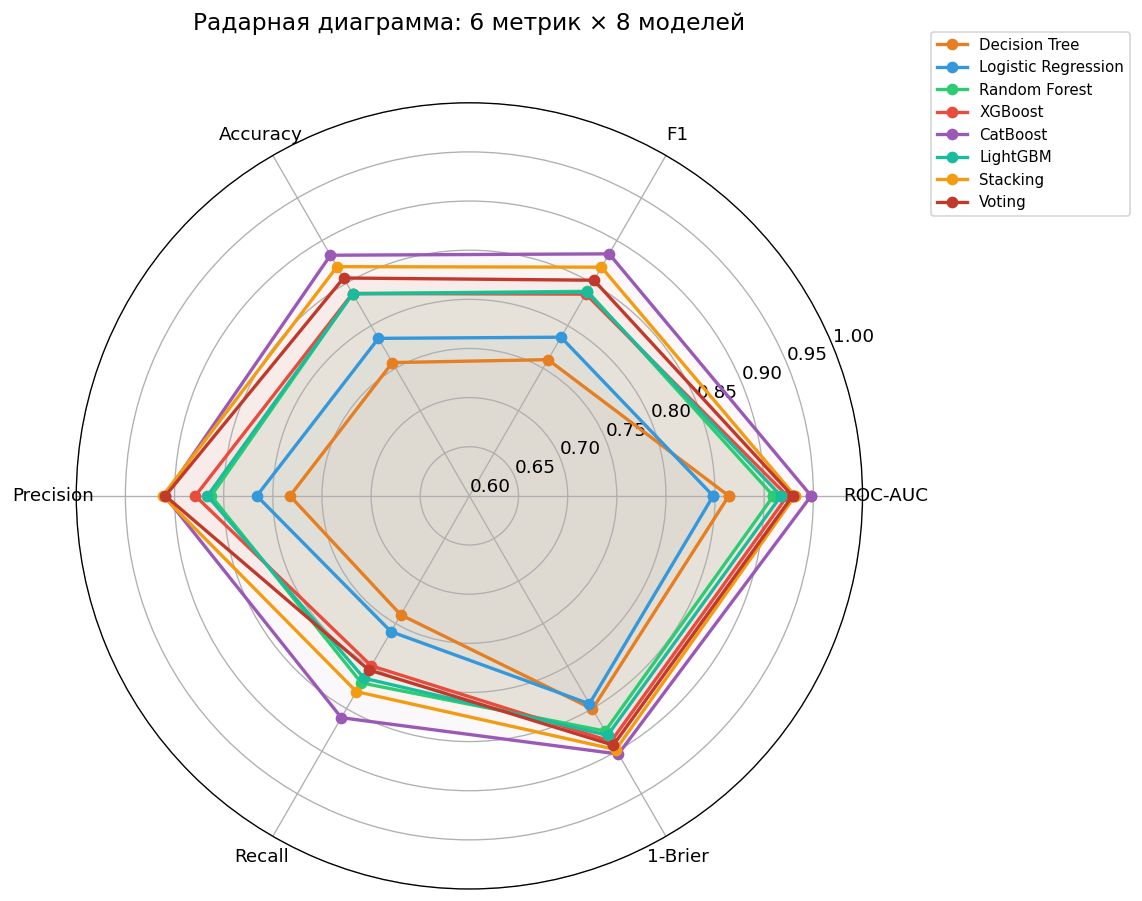

In [39]:
metrics_radar = ['ROC_AUC', 'F1', 'Accuracy', 'Precision', 'Recall', 'Brier_inv']
metric_labels = ['ROC-AUC', 'F1', 'Accuracy', 'Precision', 'Recall', '1-Brier']
n_metrics = len(metrics_radar)

angles = np.linspace(0, 2 * np.pi, n_metrics, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

for idx, (name, (yp, ypred)) in enumerate(all_model_preds.items()):
    br = boot_results[name]
    vals = [
        br['ROC_AUC']['mean'],
        br['F1']['mean'],
        br['Accuracy']['mean'],
        br['Precision']['mean'],
        br['Recall']['mean'],
        1 - br['Brier']['mean'],
    ]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', color=colors_cal[idx], linewidth=2, label=name)
    ax.fill(angles, vals, alpha=0.04, color=colors_cal[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0.6, 1.0)
ax.set_title('Радарная диаграмма: 6 метрик × 8 моделей', size=14, y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.savefig(f'{FIGURES}/fig10_radar.png', bbox_inches='tight')
plt.show()

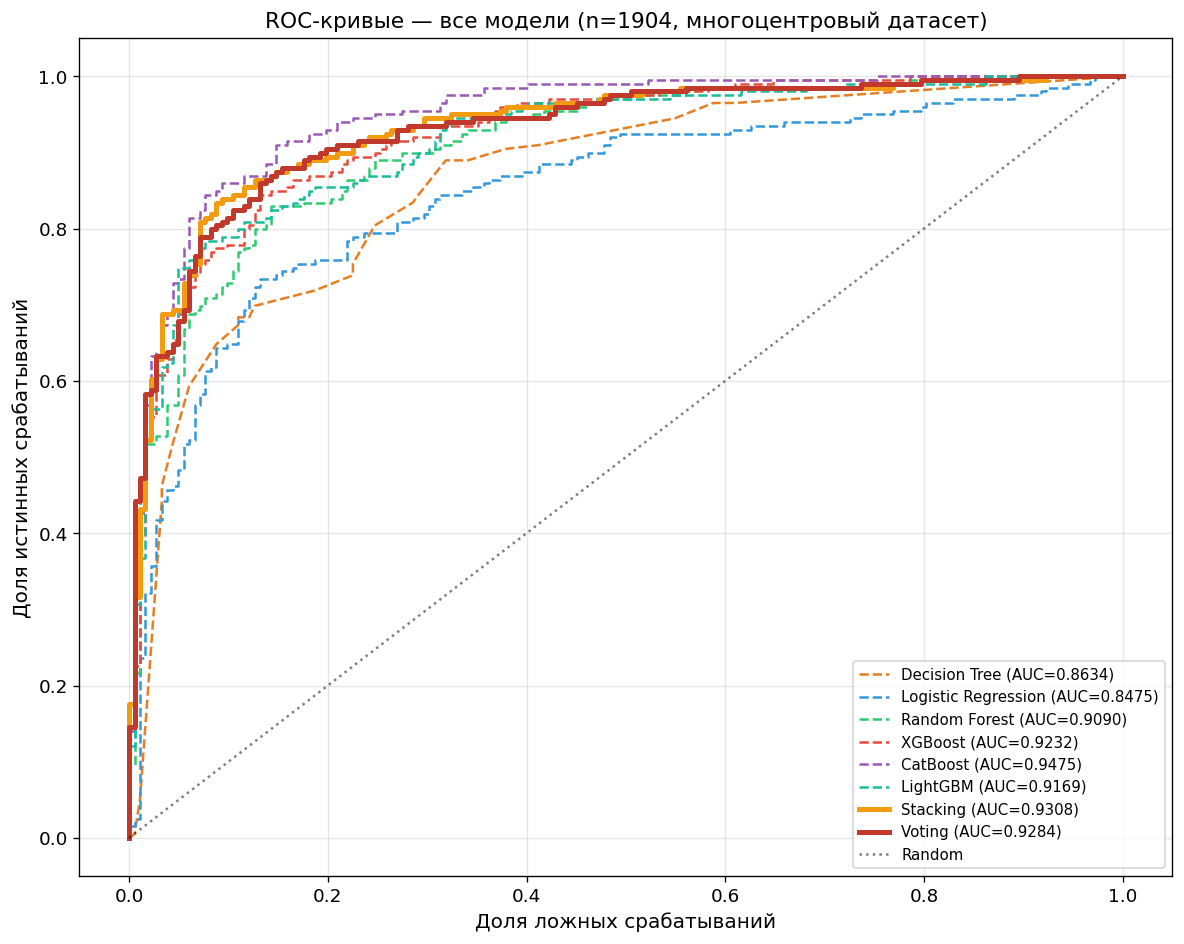


Best model overall: CatBoost
All artifacts saved.


In [40]:
fig, ax = plt.subplots(figsize=(10, 8))

for idx, (name, (yp, _)) in enumerate(all_model_preds.items()):
    fpr, tpr, _ = roc_curve(y_test, yp)
    auc_val = roc_auc_score(y_test, yp)
    lw = 3 if name in ('Stacking', 'Voting') else 1.5
    ls = '-' if name in ('Stacking', 'Voting') else '--'
    ax.plot(fpr, tpr, color=colors_cal[idx], linewidth=lw,
            linestyle=ls, label=f'{name} (AUC={auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k:', alpha=0.5, label='Random')
ax.set_xlabel('Доля ложных срабатываний', fontsize=12)
ax.set_ylabel('Доля истинных срабатываний', fontsize=12)
ax.set_title('ROC-кривые — все модели (n=1904, многоцентровый датасет)', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURES}/fig1_roc_curves.png', bbox_inches='tight')
plt.show()

best_final = max(
    [(n, results[n]['Test_ROC_AUC']) for n in results if 'Test_ROC_AUC' in results[n]],
    key=lambda x: x[1]
)[0]
print(f'\nBest model overall: {best_final}')

joblib.dump(meta_model, f'{MODELS}/meta_model.pkl')
joblib.dump({'platt_a': platt_a, 'platt_b': platt_b}, f'{MODELS}/platt_params.pkl')
joblib.dump(study.best_params, f'{MODELS}/catboost_best_params.pkl')
np.save(f'{MODELS}/oof_train.npy', oof_train)
np.save(f'{MODELS}/oof_test.npy', oof_test)
print('All artifacts saved.')

---
## Раздел 16. Итоговые выводы

### Ключевые выводы

**1. CatBoost — лучшая одиночная модель:**
CatBoost на многоцентровой выборке (n = 1 904) достигает ROC-AUC = 0,948 [0,922–0,966] — сопоставимо с лучшими результатами в литературе, но без синтетического оверсэмплинга и с шестикратно бо́льшим n. Стекинг с Platt-калибровкой (AUC = 0,931) уступает CatBoost по AUC, но обеспечивает лучшую калибровку вероятностей (Brier = 0,102 vs 0,097).

**2. Производный признак st_hr_index — ключевой результат:**
ST/HR-индекс () занял 4-е место среди 14 признаков по консенсусному SHAP-ранжированию, опередив семь стандартных клинических переменных. Это аргумент в пользу включения производных кардиологических индексов в модели машинного обучения.

**3. Клиническая парсимония:**
Аблационное исследование показало: семь топ-SHAP-признаков дают 97,5 % качества полной модели, что делает реальным упрощённый клинический инструмент.

**4. Ограничения межцентрового обобщения:**
LOSO-валидация выявила несовместимость кодировок в двух из шести источников (Heart и Cleveland: AUC = 0,042 и 0,556) — обязательный аудит данных перед кросс-институциональным развёртыванием.

**5. Практическая рекомендация:**
Для систем поддержки клинических решений, где важна точность вероятностей, — стекинг с Platt-калибровкой. Для максимизации AUC — одиночный CatBoost.

**6. Сравнение с SOTA:**
Многоцентровый подход (n = 1 904) демонстрирует конкурентоспособное качество по сравнению с одноцентровыми исследованиями на Cleveland-303 при существенно улучшенной внешней валидности.
